# PMind Chess — Notebook EDA complet (v4 corrigé)

Ce notebook construit une analyse exploratoire adaptée au rapport. Version corrigée : chargement plus robuste des données, vérifications explicites, et ajout sécurisé de la cible `elo`.


In [ ]:
# Montage Google Drive (uniquement si le notebook est exécuté sur Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive non monté automatiquement : environnement hors Colab ou module indisponible.')

Mounted at /content/drive


## 0. Installation / imports / configuration

In [ ]:
# Si vous êtes sur Google Colab, décommentez ces lignes.
# from google.colab import drive
# drive.mount('/content/drive')

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

# ===== À MODIFIER SI BESOIN =====
BASE_DIR = Path('/content/drive/MyDrive/Data Pmind 700-30')
# Pour test local si le dossier existe ailleurs :
if not BASE_DIR.exists():
    BASE_DIR = Path('/mnt/data/Data Pmind 700-30')

OUT_DIR = Path('/content/drive/MyDrive/pmind_eda_outputs')
if not OUT_DIR.parent.exists():
    OUT_DIR = Path('/mnt/data/pmind_eda_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CADENCES = ['bullet', 'blitz', 'rapid']
RANDOM_STATE = 42

print('BASE_DIR =', BASE_DIR)
print('OUT_DIR  =', OUT_DIR)
print('SciPy:', SCIPY_AVAILABLE, '| statsmodels:', STATSMODELS_AVAILABLE)

BASE_DIR = /mnt/data/Data Pmind 700-30
OUT_DIR  = /content/drive/MyDrive/pmind_eda_outputs
SciPy: True | statsmodels: True


## 1. Fonctions utilitaires

In [ ]:
def savefig(name, dpi=160):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print('Saved:', path)
    plt.show()


def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().replace(' ', '_') for c in df.columns]
    return df


def read_csv_safely(path):
    try:
        return normalize_columns(pd.read_csv(path, low_memory=False))
    except Exception as e:
        print(f'[WARN] Impossible de lire {path}: {e}')
        return pd.DataFrame()


def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    low_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in low_map:
            return low_map[c.lower()]
    return None


def numeric_cols(df, exclude=()):
    exclude = set(exclude)
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]


def iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(0.75) - x.quantile(0.25)


def robust_boxplot(df, x, y, title, ylabel, filename, max_points=None):
    tmp = df[[x, y]].dropna().copy()
    if max_points is not None and len(tmp) > max_points:
        tmp = tmp.sample(max_points, random_state=RANDOM_STATE)
    groups = [g[y].values for _, g in tmp.groupby(x)]
    labels = [str(k) for k, _ in tmp.groupby(x)]
    plt.figure(figsize=(8, 4.5))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(ylabel)
    savefig(filename)


def add_elo_bucket(df, elo_col='elo'):
    df = df.copy()
    if elo_col not in df.columns:
        return df
    bins = [1000, 1400, 1600, 1800, 2000, 2200]
    labels = ['[1000,1400[', '[1400,1600[', '[1600,1800[', '[1800,2000[', '[2000,2200]']
    if 'elo_bucket' not in df.columns:
        df['elo_bucket'] = pd.cut(df[elo_col], bins=bins, labels=labels, include_lowest=True, right=False)
    return df


def safe_corr(df, cols, target='elo', method='spearman'):
    cols = [c for c in cols if c in df.columns and c != target]
    rows = []
    for c in cols:
        tmp = df[[c, target]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(tmp) < 5 or tmp[c].nunique() <= 1:
            continue
        try:
            val = tmp[c].corr(tmp[target], method=method)
            rows.append({'feature': c, f'{method}_corr_with_elo': val, 'abs_corr': abs(val)})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values('abs_corr', ascending=False)


def first_existing_col(df, candidates):
    """Retourne la première colonne existante parmi des candidats, insensible à la casse."""
    if df is None or len(df.columns) == 0:
        return None
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if str(c).lower() in lower:
            return lower[str(c).lower()]
    return None


def ensure_numeric(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


## 2. Chargement des fichiers `players.csv`, `games.csv`, `moves.csv`

Le notebook charge les trois cadences séparément puis ajoute une colonne `speed` pour pouvoir comparer les corpus.

In [ ]:
from pathlib import Path

# Monter Google Drive si tu es sur Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Pas sur Colab ou Drive déjà monté :", e)

# Mets ici le vrai chemin vers ton dossier
BASE_DIR = Path('/content/drive/MyDrive/Data_Pmind_700-30')

print("BASE_DIR =", BASE_DIR)
print("Existe ?", BASE_DIR.exists())

if BASE_DIR.exists():
    print("Sous-dossiers trouvés :")
    for p in BASE_DIR.iterdir():
        if p.is_dir():
            print("-", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR = /content/drive/MyDrive/Data_Pmind_700-30
Existe ? True
Sous-dossiers trouvés :
- bullet
- blitz
- rapid


In [ ]:
def find_cadence_folder(base_dir, speed):
    """Trouve un sous-dossier cadence même si la casse diffère."""
    if not base_dir.exists():
        return None
    direct = base_dir / speed
    if direct.exists():
        return direct
    for p in base_dir.iterdir():
        if p.is_dir() and p.name.lower() == speed.lower():
            return p
    return None


def show_path_help(base_dir):
    print('[INFO] BASE_DIR actuel :', base_dir)
    print('[INFO] Existe ?', base_dir.exists())
    parent = base_dir.parent
    if parent.exists():
        print('[INFO] Quelques dossiers dans', parent, ':')
        for p in list(parent.iterdir())[:30]:
            if p.is_dir():
                print('  -', p.name)
    else:
        print('[INFO] Le dossier parent n’existe pas non plus :', parent)


def load_cadence_data(base_dir=BASE_DIR, cadences=CADENCES):
    players_list, games_list, moves_list = [], [], []

    if not base_dir.exists():
        show_path_help(base_dir)
        raise FileNotFoundError(
            f"BASE_DIR introuvable : {base_dir}. Modifie BASE_DIR pour pointer vers le dossier qui contient bullet/, blitz/, rapid/."
        )

    found_any = False
    for speed in cadences:
        folder = find_cadence_folder(base_dir, speed)
        if folder is None:
            print(f'[WARN] Dossier cadence introuvable pour {speed} dans {base_dir}')
            continue

        p_path, g_path, m_path = folder / 'players.csv', folder / 'games.csv', folder / 'moves.csv'
        if not p_path.exists() or not g_path.exists() or not m_path.exists():
            print(f'[WARN] Fichiers manquants dans {folder}')
            print('  players.csv existe ?', p_path.exists())
            print('  games.csv existe   ?', g_path.exists())
            print('  moves.csv existe   ?', m_path.exists())
            continue

        p = read_csv_safely(p_path)
        g = read_csv_safely(g_path)
        m = read_csv_safely(m_path)
        for df in (p, g, m):
            if len(df):
                df['speed'] = speed.lower()
        players_list.append(p)
        games_list.append(g)
        moves_list.append(m)
        found_any = True
        print(speed, '| players:', p.shape, '| games:', g.shape, '| moves:', m.shape)

    if not found_any:
        show_path_help(base_dir)
        raise FileNotFoundError(
            "Aucun dossier cadence valide trouvé. Vérifie que BASE_DIR contient bien bullet/players.csv, blitz/players.csv, rapid/players.csv, etc."
        )

    players = pd.concat(players_list, ignore_index=True) if players_list else pd.DataFrame()
    games = pd.concat(games_list, ignore_index=True) if games_list else pd.DataFrame()
    moves = pd.concat(moves_list, ignore_index=True) if moves_list else pd.DataFrame()

    if players.empty or games.empty or moves.empty:
        raise ValueError(
            f"Chargement incomplet : players={players.shape}, games={games.shape}, moves={moves.shape}."
        )
    return players, games, moves

players_raw, games_raw, moves_raw = load_cadence_data()
print('\nTOTAL players:', players_raw.shape, 'games:', games_raw.shape, 'moves:', moves_raw.shape)
print('\nColonnes players:', players_raw.columns.tolist()[:25])
print('Colonnes games:', games_raw.columns.tolist()[:25])
print('Colonnes moves:', moves_raw.columns.tolist()[:25])
display(players_raw.head())
display(games_raw.head())
display(moves_raw.head())


bullet | players: (700, 13) | games: (21000, 23) | moves: (1282007, 24)
blitz | players: (700, 13) | games: (21000, 23) | moves: (1414049, 24)
rapid | players: (486, 13) | games: (14580, 23) | moves: (984913, 24)

TOTAL players: (1886, 13) games: (56580, 23) moves: (3680969, 24)

Colonnes players: ['username', 'elo', 'elo_bucket', 'games_collected', 'mean_cp_loss', 'median_cp_loss', 'blunder_rate', 'mistake_rate', 'inaccuracy_rate', 'avg_blunders_per_game', 'avg_mistakes_per_game', 'win_rate', 'speed']
Colonnes games: ['game_id', 'date_utc', 'time_control', 'speed', 'rated', 'status', 'ply_count', 'white_name', 'black_name', 'white_elo', 'black_elo', 'white_elo_diff', 'black_elo_diff', 'opening_eco', 'opening_name', 'opening_ply', 'target_name', 'target_color', 'opponent_name', 'target_elo', 'opponent_elo', 'target_result', 'target_score']
Colonnes moves: ['game_id', 'ply', 'player_color', 'is_target_move', 'fen_before', 'phase', 'move_san', 'move_uci', 'piece_type', 'is_capture', 'is_

,username,elo,elo_bucket,games_collected,mean_cp_loss,median_cp_loss,blunder_rate,mistake_rate,inaccuracy_rate,avg_blunders_per_game,avg_mistakes_per_game,win_rate,speed
0,chatonfelix,1395,1000-1400,30,-244.65,-43.85,0.0025,0.0,0.0013,0.07,0.0,0.533,bullet
1,player_004,1191,1000-1400,30,-161.61,-28.95,0.0000,0.0,0.0034,0.00,0.0,0.300,bullet
2,mihneab,1133,1000-1400,30,-353.34,-34.05,0.0012,0.0,0.0035,0.03,0.0,0.550,bullet
3,KmlUtkuu,1175,1000-1400,30,-376.56,-21.03,0.0013,0.0,0.0040,0.03,0.0,0.433,bullet
4,Polina040715,1054,1000-1400,30,-480.63,-20.17,0.0000,0.0,0.0024,0.00,0.0,0.433,bullet


,game_id,date_utc,time_control,speed,rated,status,ply_count,white_name,black_name,white_elo,black_elo,white_elo_diff,black_elo_diff,opening_eco,opening_name,opening_ply,target_name,target_color,opponent_name,target_elo,opponent_elo,target_result,target_score
0,wGZ5gVnz,2026-04-11T20:09:20.744000+00:00,0+1,bullet,True,mate,127,chatonfelix,V0va_chess,1411,1354,5.0,-6.0,C44,Scotch Game,5,chatonfelix,white,V0va_chess,1411,1354,win,1.0
1,DENoYx44,2026-04-09T19:51:28.980000+00:00,0+1,bullet,True,outoftime,54,TurBoWhite,chatonfelix,1408,1414,-6.0,6.0,A00,Hungarian Opening,1,chatonfelix,black,TurBoWhite,1414,1408,win,1.0
2,9ar5gzjH,2026-04-09T19:49:41.623000+00:00,0+1,bullet,True,outoftime,49,TurBoWhite,chatonfelix,1408,1414,5.0,-5.0,A01,Nimzo-Larsen Attack,1,chatonfelix,black,TurBoWhite,1414,1408,loss,0.0
3,G90QRLek,2026-04-09T19:40:14.073000+00:00,0+1,bullet,True,outoftime,48,chatonfelix,TurBoWhite,1450,1372,-7.0,7.0,B00,Owen Defense,2,chatonfelix,white,TurBoWhite,1450,1372,loss,0.0
4,AvADrX9u,2026-04-09T13:36:28.661000+00:00,0+1,bullet,True,mate,54,manu_bsas,chatonfelix,1405,1446,-5.0,6.0,A00,Saragossa Opening,1,chatonfelix,black,manu_bsas,1446,1405,win,1.0


,game_id,ply,player_color,is_target_move,fen_before,phase,move_san,move_uci,piece_type,is_capture,is_check,is_castle,is_promotion,promotion_piece,best_move_san,best_move_uci,eval_white_before,eval_white_after,cp_loss,move_quality,clock_before_cs,clock_after_cs,time_spent_cs,speed
0,wGZ5gVnz,1,white,True,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,opening,e4,e2e4,Pawn,False,False,False,False,NaN,NaN,NaN,18,22,-4.0,Good,0,300,0,bullet
1,wGZ5gVnz,2,black,False,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,opening,e5,e7e5,Pawn,False,False,False,False,NaN,NaN,NaN,22,18,NaN,NaN,0,300,0,bullet
2,wGZ5gVnz,3,white,True,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,opening,Nf3,g1f3,Knight,False,False,False,False,NaN,NaN,NaN,18,22,-4.0,Good,300,360,0,bullet
3,wGZ5gVnz,4,black,False,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,opening,Nc6,b8c6,Knight,False,False,False,False,NaN,NaN,NaN,22,7,NaN,NaN,300,375,0,bullet
4,wGZ5gVnz,5,white,True,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,opening,d4,d2d4,Pawn,False,False,False,False,NaN,NaN,NaN,7,67,-60.0,Good,360,460,0,bullet


## 3. Harmonisation minimale des colonnes importantes

In [ ]:
players = players_raw.copy()
games = games_raw.copy()
moves = moves_raw.copy()

# Colonnes principales
player_name_col = find_col(players, ['username', 'target_name', 'name', 'player', 'user'])
elo_col = find_col(players, ['elo', 'rating', 'mean_elo', 'target_elo'])

if player_name_col and player_name_col != 'target_name':
    players = players.rename(columns={player_name_col: 'target_name'})
if elo_col and elo_col != 'elo':
    players = players.rename(columns={elo_col: 'elo'})

players = add_elo_bucket(players, 'elo')

# games : harmoniser game_id, target_name, target_color si possible
for old, new in [('id', 'game_id'), ('gameId', 'game_id')]:
    if old in games.columns and 'game_id' not in games.columns:
        games = games.rename(columns={old: new})

# moves : harmoniser game_id
for old, new in [('id', 'game_id'), ('gameId', 'game_id')]:
    if old in moves.columns and 'game_id' not in moves.columns:
        moves = moves.rename(columns={old: new})

print('players columns:', list(players.columns)[:30])
print('games columns:', list(games.columns)[:30])
print('moves columns:', list(moves.columns)[:30])

players columns: ['target_name', 'elo', 'elo_bucket', 'games_collected', 'mean_cp_loss', 'median_cp_loss', 'blunder_rate', 'mistake_rate', 'inaccuracy_rate', 'avg_blunders_per_game', 'avg_mistakes_per_game', 'win_rate', 'speed']
games columns: ['game_id', 'date_utc', 'time_control', 'speed', 'rated', 'status', 'ply_count', 'white_name', 'black_name', 'white_elo', 'black_elo', 'white_elo_diff', 'black_elo_diff', 'opening_eco', 'opening_name', 'opening_ply', 'target_name', 'target_color', 'opponent_name', 'target_elo', 'opponent_elo', 'target_result', 'target_score']
moves columns: ['game_id', 'ply', 'player_color', 'is_target_move', 'fen_before', 'phase', 'move_san', 'move_uci', 'piece_type', 'is_capture', 'is_check', 'is_castle', 'is_promotion', 'promotion_piece', 'best_move_san', 'best_move_uci', 'eval_white_before', 'eval_white_after', 'cp_loss', 'move_quality', 'clock_before_cs', 'clock_after_cs', 'time_spent_cs', 'speed']


## 4. Construction de features EDA au niveau coup, partie et joueur

Cette partie reconstruit seulement les features nécessaires à l’EDA. Elle ne remplace pas le pipeline complet de modélisation.

In [ ]:
def prepare_moves_for_eda(moves, games=None):
    m = moves.copy()
    if len(m) == 0:
        return m

    # Filtrer les coups du joueur cible si disponible
    is_target_col = find_col(m, ['is_target_move', 'target_move'])
    if is_target_col:
        mask = m[is_target_col].astype(str).str.lower().isin(['true', '1', 'yes', 't']) | (m[is_target_col] == 1) | (m[is_target_col] == True)
        # Si le filtrage supprime tout, on garde les données et on affiche un avertissement.
        if mask.sum() > 0:
            m = m[mask].copy()
        else:
            print('[WARN] is_target_move existe mais aucun coup cible détecté. Aucun filtrage appliqué.')

    # cp_loss_clean
    cp_col = find_col(m, ['cp_loss', 'loss_cp', 'centipawn_loss'])
    if cp_col:
        m['cp_loss_clean'] = pd.to_numeric(m[cp_col], errors='coerce').abs().clip(upper=600)
    elif 'cp_loss_clean' not in m.columns:
        m['cp_loss_clean'] = np.nan

    # Qualité des coups : si move_quality existe, on l'utilise ; sinon seuils cp_loss_clean.
    q_col = find_col(m, ['move_quality', 'quality'])
    if q_col:
        q = m[q_col].astype(str).str.lower()
        m['is_good'] = q.str.contains('good').astype(int)
        m['is_inaccuracy'] = q.str.contains('inacc').astype(int)
        m['is_mistake'] = q.str.contains('mistake').astype(int)
        m['is_blunder'] = q.str.contains('blunder').astype(int)
        m['is_error'] = ((m['is_inaccuracy'] + m['is_mistake'] + m['is_blunder']) > 0).astype(int)
    else:
        c = m['cp_loss_clean']
        m['is_good'] = (c < 50).astype(int)
        m['is_inaccuracy'] = ((c >= 50) & (c < 100)).astype(int)
        m['is_mistake'] = ((c >= 100) & (c < 200)).astype(int)
        m['is_blunder'] = (c >= 200).astype(int)
        m['is_error'] = (c >= 50).astype(int)

    # Temps
    tsp_col = find_col(m, ['time_spent_cs', 'time_spent', 'time_used_cs'])
    if tsp_col:
        m[tsp_col] = pd.to_numeric(m[tsp_col], errors='coerce').fillna(0)
        if tsp_col.endswith('_cs'):
            m['time_spent_s'] = m[tsp_col] / 100.0
        else:
            m['time_spent_s'] = m[tsp_col]
    else:
        m['time_spent_s'] = np.nan

    clk_col = find_col(m, ['clock_before_cs', 'clock_before', 'clock_s'])
    if clk_col:
        m[clk_col] = pd.to_numeric(m[clk_col], errors='coerce')
        med = m[clk_col].median()
        m[clk_col] = m[clk_col].fillna(med)
        if clk_col.endswith('_cs'):
            m['clock_before_s'] = m[clk_col] / 100.0
        else:
            m['clock_before_s'] = m[clk_col]
    else:
        m['clock_before_s'] = np.nan

    # Phase
    phase_col = find_col(m, ['phase'])
    if phase_col:
        m['phase_clean'] = m[phase_col].astype(str).str.lower()
    else:
        ply_col = find_col(m, ['ply', 'ply_count', 'move_number'])
        if ply_col:
            ply = pd.to_numeric(m[ply_col], errors='coerce')
            m['phase_clean'] = np.select([ply <= 20, ply <= 60], ['opening', 'middlegame'], default='endgame')
        else:
            m['phase_clean'] = 'unknown'

    # Tactique
    for col in ['is_capture', 'is_check', 'is_castle', 'is_promotion']:
        src = find_col(m, [col])
        if src:
            m[col] = m[src].astype(str).str.lower().isin(['true', '1', 'yes']).astype(int) if m[src].dtype == object else pd.to_numeric(m[src], errors='coerce').fillna(0).astype(int)
        else:
            m[col] = 0

    # Fusionner target_name / target_color depuis games si nécessaire
    if games is not None and 'game_id' in m.columns and 'game_id' in games.columns:
        add_cols = ['game_id']
        for c in ['target_name', 'target_color', 'target_elo', 'opening_eco', 'target_score']:
            if c in games.columns:
                add_cols.append(c)
        if len(add_cols) > 1:
            m = m.merge(games[add_cols].drop_duplicates('game_id'), on='game_id', how='left', suffixes=('', '_g'))

    # Contexte positionnel si évaluation moteur disponible
    eval_col = find_col(m, ['eval_white_before', 'eval_before', 'cp_before'])
    if eval_col:
        ev = pd.to_numeric(m[eval_col], errors='coerce').clip(-900, 900)
        if 'target_color' in m.columns:
            color = m['target_color'].astype(str).str.lower()
            m['eval_player_before'] = np.where(color.str.startswith('b'), -ev, ev)
        else:
            m['eval_player_before'] = ev
        m['pos_context'] = np.select(
            [m['eval_player_before'] > 150, m['eval_player_before'] < -150],
            ['winning', 'losing'],
            default='equal'
        )
    else:
        m['eval_player_before'] = np.nan
        m['pos_context'] = 'unknown'

    return m

moves_eda = prepare_moves_for_eda(moves, games)
print('moves_eda:', moves_eda.shape)
display(moves_eda.head())


moves_eda: (1840473, 40)


,game_id,ply,player_color,is_target_move,fen_before,phase,move_san,move_uci,piece_type,is_capture,is_check,is_castle,is_promotion,promotion_piece,best_move_san,best_move_uci,eval_white_before,eval_white_after,cp_loss,move_quality,clock_before_cs,clock_after_cs,time_spent_cs,speed,cp_loss_clean,is_good,is_inaccuracy,is_mistake,is_blunder,is_error,time_spent_s,clock_before_s,phase_clean,target_name,target_color,target_elo,opening_eco,target_score,eval_player_before,pos_context
0,wGZ5gVnz,1,white,True,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,opening,e4,e2e4,Pawn,0,0,0,0,NaN,NaN,NaN,18,22,-4.0,Good,0,300,0,bullet,4.0,1,0,0,0,0,0.0,0.0,opening,chatonfelix,white,1411,C44,1.0,18,equal
1,wGZ5gVnz,3,white,True,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,opening,Nf3,g1f3,Knight,0,0,0,0,NaN,NaN,NaN,18,22,-4.0,Good,300,360,0,bullet,4.0,1,0,0,0,0,0.0,3.0,opening,chatonfelix,white,1411,C44,1.0,18,equal
2,wGZ5gVnz,5,white,True,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,opening,d4,d2d4,Pawn,0,0,0,0,NaN,NaN,NaN,7,67,-60.0,Good,360,460,0,bullet,60.0,1,0,0,0,0,0.0,3.6,opening,chatonfelix,white,1411,C44,1.0,7,equal
3,wGZ5gVnz,7,white,True,r1bqkbnr/ppp2ppp/2np4/4p3/3PP3/5N2/PPP2PPP/RNB...,opening,Bc4,f1c4,Bishop,0,0,0,0,NaN,NaN,NaN,35,197,-162.0,Good,460,550,0,bullet,162.0,1,0,0,0,0,0.0,4.6,opening,chatonfelix,white,1411,C44,1.0,35,equal
4,wGZ5gVnz,9,white,True,r1bqkbnr/ppp2ppp/2n5/3pp3/2BPP3/5N2/PPP2PPP/RN...,opening,Bxd5,c4d5,Bishop,1,0,0,0,NaN,NaN,NaN,150,610,-460.0,Good,550,556,0,bullet,460.0,1,0,0,0,0,0.0,5.5,opening,chatonfelix,white,1411,C44,1.0,150,equal


In [ ]:
def build_game_features(m):
    if len(m) == 0 or 'game_id' not in m.columns:
        return pd.DataFrame()
    keys = ['speed', 'target_name', 'game_id']
    keys = [k for k in keys if k in m.columns]
    grp = m.groupby(keys, dropna=False)
    g = grp.agg(
        n_moves=('cp_loss_clean', 'size'),
        loss_mean=('cp_loss_clean', 'mean'),
        loss_median=('cp_loss_clean', 'median'),
        loss_std=('cp_loss_clean', 'std'),
        loss_p90=('cp_loss_clean', lambda x: np.nanpercentile(x.dropna(), 90) if x.dropna().size else np.nan),
        loss_max=('cp_loss_clean', 'max'),
        rate_good=('is_good', 'mean'),
        rate_inaccuracy=('is_inaccuracy', 'mean'),
        rate_mistake=('is_mistake', 'mean'),
        rate_blunder=('is_blunder', 'mean'),
        rate_error=('is_error', 'mean'),
        n_blunders=('is_blunder', 'sum'),
        n_mistakes=('is_mistake', 'sum'),
        time_mean_s=('time_spent_s', 'mean'),
        time_median_s=('time_spent_s', 'median'),
        time_std_s=('time_spent_s', 'std'),
        clock_mean_s=('clock_before_s', 'mean'),
        rate_capture=('is_capture', 'mean'),
        rate_check=('is_check', 'mean'),
        rate_castle=('is_castle', 'mean'),
        rate_promotion=('is_promotion', 'mean'),
    ).reset_index()

    # Phases : loss and blunder rates by phase
    for ph in ['opening', 'middlegame', 'endgame']:
        sub = m[m['phase_clean'].astype(str).str.contains(ph, na=False)]
        if len(sub):
            gp = sub.groupby(keys, dropna=False).agg(
                **{f'loss_{ph}_mean': ('cp_loss_clean', 'mean'),
                   f'rate_blunder_{ph}': ('is_blunder', 'mean'),
                   f'time_{ph}_mean_s': ('time_spent_s', 'mean')}
            ).reset_index()
            g = g.merge(gp, on=keys, how='left')

    # Position context losses
    for ctx in ['winning', 'equal', 'losing']:
        sub = m[m['pos_context'] == ctx]
        if len(sub):
            gp = sub.groupby(keys, dropna=False).agg(
                **{f'loss_when_{ctx}': ('cp_loss_clean', 'mean'),
                   f'rate_blunder_when_{ctx}': ('is_blunder', 'mean')}
            ).reset_index()
            g = g.merge(gp, on=keys, how='left')

    # Time-pressure features
    # Low clock threshold: bottom 20% within cadence or <=10s fallback
    if 'clock_before_s' in m.columns:
        tmp = m.copy()
        tmp['low_clock'] = False
        for sp, sub in tmp.groupby('speed') if 'speed' in tmp.columns else [('all', tmp)]:
            q = sub['clock_before_s'].quantile(0.2)
            threshold = min(q, 10) if pd.notna(q) else 10
            tmp.loc[sub.index, 'low_clock'] = sub['clock_before_s'] <= threshold
        gp = tmp.groupby(keys, dropna=False).agg(
            blunder_low_time_rate=('is_blunder', lambda x: np.nan),
            good_fast_move_rate=('is_good', lambda x: np.nan)
        ).reset_index().drop(columns=['blunder_low_time_rate','good_fast_move_rate'])
        # Compute explicitly
        res=[]
        for k, sub in tmp.groupby(keys, dropna=False):
            if not isinstance(k, tuple): k=(k,)
            low = sub[sub['low_clock']]
            fast_thr = sub['time_spent_s'].quantile(0.25)
            fast = sub[sub['time_spent_s'] <= fast_thr]
            row = dict(zip(keys,k))
            row['blunder_low_time_rate'] = low['is_blunder'].mean() if len(low) else np.nan
            row['good_fast_move_rate'] = fast['is_good'].mean() if len(fast) else np.nan
            res.append(row)
        gp = pd.DataFrame(res)
        g = g.merge(gp, on=keys, how='left')

    # Drift within game: last third - first third loss
    ply_col = find_col(m, ['ply'])
    if ply_col:
        res=[]
        for k, sub in m.groupby(keys, dropna=False):
            if not isinstance(k, tuple): k=(k,)
            ss = sub.sort_values(ply_col)
            n = len(ss)
            row = dict(zip(keys,k))
            if n >= 6:
                a = ss.iloc[:max(1,n//3)]['cp_loss_clean'].mean()
                b = ss.iloc[-max(1,n//3):]['cp_loss_clean'].mean()
                row['loss_drift_end_vs_start'] = b - a
            else:
                row['loss_drift_end_vs_start'] = np.nan
            res.append(row)
        drift = pd.DataFrame(res)
        g = g.merge(drift, on=keys, how='left')

    return g

game_features = build_game_features(moves_eda)
print('game_features:', game_features.shape)
display(game_features.head())

game_features: (56580, 42)


,speed,target_name,game_id,n_moves,loss_mean,loss_median,loss_std,loss_p90,loss_max,rate_good,rate_inaccuracy,rate_mistake,rate_blunder,rate_error,n_blunders,n_mistakes,time_mean_s,time_median_s,time_std_s,clock_mean_s,rate_capture,rate_check,rate_castle,rate_promotion,loss_opening_mean,rate_blunder_opening,time_opening_mean_s,loss_middlegame_mean,rate_blunder_middlegame,time_middlegame_mean_s,loss_endgame_mean,rate_blunder_endgame,time_endgame_mean_s,loss_when_winning,rate_blunder_when_winning,loss_when_equal,rate_blunder_when_equal,loss_when_losing,rate_blunder_when_losing,blunder_low_time_rate,good_fast_move_rate,loss_drift_end_vs_start
0,blitz,player_001,1u9LK0k6,46,55.195652,13.5,123.994735,143.0,600.0,1.000000,0.0,0.000000,0.0,0.000000,0,0,2.700870,1.48,3.879067,133.551087,0.217391,0.086957,0.021739,0.00000,13.8,0.0,0.856,66.694444,0.0,3.213333,NaN,NaN,NaN,NaN,NaN,12.636364,0.0,68.571429,0.0,NaN,1.000000,59.466667
1,blitz,player_001,345RCcKy,52,47.153846,16.5,61.015069,117.4,321.0,1.000000,0.0,0.000000,0.0,0.000000,0,0,3.267692,1.72,4.855248,87.872500,0.250000,0.038462,0.019231,0.00000,17.4,0.0,2.048,57.333333,0.0,5.933333,51.916667,0.0,1.776667,53.000000,0.0,33.888889,0.0,62.217391,0.0,NaN,1.000000,30.764706
2,blitz,player_001,35Ng1E1T,70,41.971429,9.0,101.068204,145.1,600.0,1.000000,0.0,0.000000,0.0,0.000000,0,0,2.123286,1.16,2.378445,98.753000,0.171429,0.085714,0.014286,0.00000,15.5,0.0,0.904,46.383333,0.0,2.326500,NaN,NaN,NaN,NaN,NaN,12.774194,0.0,65.179487,0.0,NaN,1.000000,26.304348
3,blitz,player_001,4Kr0cXwA,45,81.511111,21.0,153.351886,161.6,600.0,0.977778,0.0,0.022222,0.0,0.022222,0,1,2.270222,1.28,2.616329,134.697778,0.333333,0.022222,0.022222,0.00000,18.8,0.0,0.848,43.142857,0.0,3.405714,136.952381,0.0,2.190476,165.500000,0.0,40.482759,0.0,88.500000,0.0,NaN,0.916667,162.066667
4,blitz,player_001,69rn7rC0,41,60.707317,15.0,124.131431,123.0,600.0,1.000000,0.0,0.000000,0.0,0.000000,0,0,4.107317,2.80,5.206353,99.654634,0.268293,0.292683,0.024390,0.02439,14.8,0.0,5.296,75.516129,0.0,3.723871,NaN,NaN,NaN,94.176471,0.0,21.111111,0.0,84.666667,0.0,NaN,1.000000,64.307692


In [ ]:
def build_player_features(game_features, players, games=None):
    """
    Construit des features player-level à partir de game_features et ajoute la cible Elo.
    La fonction est robuste aux variations de noms de colonnes : elo, target_elo, mean_elo, rating, etc.
    """
    if len(game_features) == 0:
        return pd.DataFrame()

    gf = game_features.copy()
    p = players.copy() if players is not None else pd.DataFrame()
    gms = games.copy() if games is not None else pd.DataFrame()

    # Clés d'agrégation player-level
    keys = ['speed', 'target_name']
    keys = [k for k in keys if k in gf.columns]
    if 'target_name' not in keys:
        print('[WARN] target_name absent de game_features. Agrégation seulement par cadence si speed existe.')

    # Agrégation des variables numériques au niveau joueur
    feature_cols = [c for c in gf.select_dtypes(include=[np.number]).columns if c not in ['game_id']]
    agg = {}
    for c in feature_cols:
        agg[f'{c}_mean'] = (c, 'mean')
        agg[f'{c}_median'] = (c, 'median')
        agg[f'{c}_std'] = (c, 'std')
        agg[f'{c}_iqr'] = (c, iqr)

    pf = gf.groupby(keys, dropna=False).agg(**agg).reset_index() if keys else pd.DataFrame()
    if keys:
        pf['n_games'] = gf.groupby(keys, dropna=False).size().values

    # Ajout win_rate depuis games si disponible
    if games is not None and len(gms) and 'target_score' in gms.columns and 'game_id' in gf.columns and 'game_id' in gms.columns:
        temp = gf[keys + ['game_id']].merge(gms[['game_id','target_score']].drop_duplicates('game_id'), on='game_id', how='left')
        wr = temp.groupby(keys, dropna=False)['target_score'].mean().reset_index(name='win_rate')
        pf = pf.merge(wr, on=keys, how='left')

    # ECO diversity depuis games si disponible
    if games is not None and len(gms) and 'opening_eco' in gms.columns and 'game_id' in gf.columns and 'game_id' in gms.columns:
        temp = gf[keys + ['game_id']].merge(gms[['game_id','opening_eco']].drop_duplicates('game_id'), on='game_id', how='left')
        temp['eco_family'] = temp['opening_eco'].astype(str).str[0]
        eco = temp.groupby(keys, dropna=False)['eco_family'].nunique().reset_index(name='eco_diversity')
        pf = pf.merge(eco, on=keys, how='left')

    # ----- Ajout de la cible Elo -----
    # 1) Source principale : players.csv
    if len(p):
        # Harmoniser nom joueur et Elo dans players si nécessaire
        name_col = first_existing_col(p, ['target_name', 'username', 'name', 'player', 'user'])
        elo_source_col = first_existing_col(p, ['elo', 'target_elo', 'mean_elo', 'rating', 'player_elo'])
        if name_col and name_col != 'target_name':
            p = p.rename(columns={name_col: 'target_name'})
        if elo_source_col and elo_source_col != 'elo':
            p = p.rename(columns={elo_source_col: 'elo'})
        if 'elo' in p.columns:
            p = ensure_numeric(p, 'elo')
            p = add_elo_bucket(p, 'elo')
            target_cols = ['target_name', 'elo']
            if 'speed' in p.columns and 'speed' in pf.columns:
                target_cols = ['speed'] + target_cols
            if 'elo_bucket' in p.columns:
                target_cols.append('elo_bucket')
            target_cols = [c for c in target_cols if c in p.columns]
            base = p[target_cols].drop_duplicates()
            merge_keys = ['target_name']
            if 'speed' in base.columns and 'speed' in pf.columns:
                merge_keys = ['speed', 'target_name']
            if 'target_name' in pf.columns:
                pf = pf.merge(base, on=merge_keys, how='left')

    # 2) Fallback : games.csv si Elo encore absent ou trop manquant
    need_fallback = ('elo' not in pf.columns) or (pf['elo'].isna().all() if 'elo' in pf.columns else True)
    if need_fallback and games is not None and len(gms):
        elo_game_col = first_existing_col(gms, ['target_elo', 'elo', 'white_elo', 'black_elo'])
        name_game_col = first_existing_col(gms, ['target_name', 'username', 'name', 'player'])
        if elo_game_col and name_game_col:
            tmp = gms.copy()
            if name_game_col != 'target_name':
                tmp = tmp.rename(columns={name_game_col: 'target_name'})
            tmp['elo_from_games'] = pd.to_numeric(tmp[elo_game_col], errors='coerce')
            target_cols = ['target_name', 'elo_from_games']
            if 'speed' in tmp.columns and 'speed' in pf.columns:
                target_cols = ['speed'] + target_cols
            base = tmp[target_cols].dropna(subset=['elo_from_games']).groupby([c for c in target_cols if c != 'elo_from_games'], dropna=False)['elo_from_games'].median().reset_index()
            merge_keys = ['target_name']
            if 'speed' in base.columns and 'speed' in pf.columns:
                merge_keys = ['speed', 'target_name']
            if 'target_name' in pf.columns:
                pf = pf.merge(base, on=merge_keys, how='left')
                if 'elo' not in pf.columns:
                    pf['elo'] = pf['elo_from_games']
                else:
                    pf['elo'] = pf['elo'].fillna(pf['elo_from_games'])
                pf = pf.drop(columns=['elo_from_games'])

    if 'elo' in pf.columns:
        pf = ensure_numeric(pf, 'elo')
        pf = add_elo_bucket(pf, 'elo')
    else:
        print('[WARN] Aucune colonne Elo trouvée après fusion. Les analyses liées à la cible ne pourront pas être exécutées.')

    return pf

player_features = build_player_features(game_features, players, games)
print('player_features:', player_features.shape)
print('Colonnes contenant elo :', [c for c in player_features.columns if 'elo' in c.lower()])
if 'elo' in player_features.columns:
    print('Valeurs Elo manquantes :', player_features['elo'].isna().sum())
display(player_features.head())

# Export dataset EDA
player_features.to_csv(OUT_DIR / 'eda_player_features.csv', index=False)
game_features.to_csv(OUT_DIR / 'eda_game_features.csv', index=False)
print('Saved player/game features to', OUT_DIR)

player_features: (1886, 163)
Colonnes contenant elo : ['elo', 'elo_bucket']
Valeurs Elo manquantes : 0


,speed,target_name,n_moves_mean,n_moves_median,n_moves_std,n_moves_iqr,loss_mean_mean,loss_mean_median,loss_mean_std,loss_mean_iqr,loss_median_mean,loss_median_median,loss_median_std,loss_median_iqr,loss_std_mean,loss_std_median,loss_std_std,loss_std_iqr,loss_p90_mean,loss_p90_median,loss_p90_std,loss_p90_iqr,loss_max_mean,loss_max_median,loss_max_std,loss_max_iqr,rate_good_mean,rate_good_median,rate_good_std,rate_good_iqr,rate_inaccuracy_mean,rate_inaccuracy_median,rate_inaccuracy_std,rate_inaccuracy_iqr,rate_mistake_mean,rate_mistake_median,rate_mistake_std,rate_mistake_iqr,rate_blunder_mean,rate_blunder_median,rate_blunder_std,rate_blunder_iqr,rate_error_mean,rate_error_median,rate_error_std,rate_error_iqr,n_blunders_mean,n_blunders_median,n_blunders_std,n_blunders_iqr,n_mistakes_mean,n_mistakes_median,n_mistakes_std,n_mistakes_iqr,time_mean_s_mean,time_mean_s_median,time_mean_s_std,time_mean_s_iqr,time_median_s_mean,time_median_s_median,...,rate_blunder_middlegame_median,rate_blunder_middlegame_std,rate_blunder_middlegame_iqr,time_middlegame_mean_s_mean,time_middlegame_mean_s_median,time_middlegame_mean_s_std,time_middlegame_mean_s_iqr,loss_endgame_mean_mean,loss_endgame_mean_median,loss_endgame_mean_std,loss_endgame_mean_iqr,rate_blunder_endgame_mean,rate_blunder_endgame_median,rate_blunder_endgame_std,rate_blunder_endgame_iqr,time_endgame_mean_s_mean,time_endgame_mean_s_median,time_endgame_mean_s_std,time_endgame_mean_s_iqr,loss_when_winning_mean,loss_when_winning_median,loss_when_winning_std,loss_when_winning_iqr,rate_blunder_when_winning_mean,rate_blunder_when_winning_median,rate_blunder_when_winning_std,rate_blunder_when_winning_iqr,loss_when_equal_mean,loss_when_equal_median,loss_when_equal_std,loss_when_equal_iqr,rate_blunder_when_equal_mean,rate_blunder_when_equal_median,rate_blunder_when_equal_std,rate_blunder_when_equal_iqr,loss_when_losing_mean,loss_when_losing_median,loss_when_losing_std,loss_when_losing_iqr,rate_blunder_when_losing_mean,rate_blunder_when_losing_median,rate_blunder_when_losing_std,rate_blunder_when_losing_iqr,blunder_low_time_rate_mean,blunder_low_time_rate_median,blunder_low_time_rate_std,blunder_low_time_rate_iqr,good_fast_move_rate_mean,good_fast_move_rate_median,good_fast_move_rate_std,good_fast_move_rate_iqr,loss_drift_end_vs_start_mean,loss_drift_end_vs_start_median,loss_drift_end_vs_start_std,loss_drift_end_vs_start_iqr,n_games,win_rate,eco_diversity,elo,elo_bucket
0,blitz,player_001,41.700000,42.0,16.877142,21.50,61.307663,56.682242,23.881345,30.063989,15.866667,14.50,6.778431,6.500,117.986643,124.063083,48.517606,50.395306,166.930000,144.85,86.917921,65.050,505.466667,600.0,178.549275,0.00,0.991719,1.0,0.014736,0.013393,0.004425,0.0,0.010167,0.0,0.002365,0.0,0.006268,0.0,0.001491,0.0,0.004572,0.0,0.008281,0.0,0.014736,0.013393,0.100000,0.0,0.305129,0.0,0.133333,0.0,0.345746,0.0,3.073259,2.872717,1.386692,1.449591,1.644167,1.42,...,0.0,0.000000,0.0,4.080759,3.440000,2.071024,2.445000,85.753778,89.376603,57.538190,49.051734,0.005746,0.0,0.011426,0.0,2.378498,2.249833,0.773704,0.771993,102.034852,89.500000,98.232624,63.846154,0.052381,0.0,0.218218,0.0,40.730006,33.867521,25.119921,30.833265,0.0,0.0,0.0,0.0,93.946984,74.571429,89.740730,25.030193,0.000805,0.0,0.003861,0.0,0.029947,0.000000,0.042546,0.058824,0.985829,1.0,0.029395,0.0,74.467053,63.472028,65.730345,73.042017,30,0.700000,4,2063,2000-2200
1,blitz,player_015,28.533333,28.5,8.315890,11.75,86.825771,95.369792,46.549292,61.713661,30.533333,24.75,25.840336,24.500,136.815133,145.095343,62.472617,104.585489,273.400000,231.80,196.099027,362.675,488.500000,600.0,179.329739,242.25,0.994588,1.0,0.011139,0.000000,0.003555,0.0,0.009359,0.0,0.000000,0.0,0.000000,0.0,0.001858,0.0,0.007081,0.0,0.005412,0.0,0.011139,0.000000,0.066667,0.0,0.253708,0.0,0.000000,0.0,0.000000,0.0,6.284665,5.319398,3.271572,2.287546,3.158667,3.06,...,0.0,0.006762,0.0,5.760834,6.020500,2.143775,3.463665,87.838836,110.298319,57.673651,97.740278,0.013889,0.0,0.039284,0

Saved player/game features to /content/drive/MyDrive/pmind_eda_outputs


In [ ]:
# Sanity check après construction des features player-level
print('game_features:', game_features.shape)
print('player_features:', player_features.shape)

if game_features.empty:
    print('\n[DEBUG] moves_eda colonnes:', moves_eda.columns.tolist()[:50])
    print('[DEBUG] moves_eda shape:', moves_eda.shape)
    raise ValueError(
        "game_features est vide. Causes probables : moves.csv non chargé, colonne game_id absente, ou filtrage is_target_move trop strict."
    )

if player_features.empty:
    print('\n[DEBUG] game_features colonnes:', game_features.columns.tolist()[:50])
    raise ValueError(
        "player_features est vide. Vérifier que game_features contient au moins speed/target_name et des variables numériques."
    )

print('\nColonnes d’identification dans player_features :')
print([c for c in player_features.columns if any(k in c.lower() for k in ['name', 'user', 'player', 'speed'])])

print('\nColonnes cible / Elo dans player_features :')
print([c for c in player_features.columns if 'elo' in c.lower()])

if 'elo' not in player_features.columns:
    print('\n[DEBUG] Colonnes players:', players.columns.tolist())
    print('[DEBUG] Colonnes games:', games.columns.tolist()[:80])
    print('[DEBUG] Colonnes player_features:', player_features.columns.tolist()[:80])
    raise ValueError(
        "La colonne 'elo' est absente de player_features. Vérifier que players.csv contient une colonne elo/rating/mean_elo et une colonne username/target_name."
    )

print('\nNombre de profils :', len(player_features))
print('Elo non manquants :', player_features['elo'].notna().sum())
cols_preview = [c for c in ['speed','target_name','elo','elo_bucket','n_games'] if c in player_features.columns]
display(player_features[cols_preview].head() if cols_preview else player_features.head())


game_features: (56580, 42)
player_features: (1886, 163)

Colonnes d’identification dans player_features :
['speed', 'target_name']

Colonnes cible / Elo dans player_features :
['elo', 'elo_bucket']

Nombre de profils : 1886
Elo non manquants : 1886


,speed,target_name,elo,elo_bucket,n_games
0,blitz,player_001,2063,2000-2200,30
1,blitz,player_015,1104,1000-1400,30
2,blitz,player_011,1868,1800-2000,30
3,blitz,player_007,1345,1000-1400,30
4,blitz,player_004,1264,1000-1400,30


# Partie A — Variable cible : `elo`

In [ ]:
dfp = player_features.copy()

if 'elo' not in dfp.columns:
    raise ValueError("Colonne 'elo' absente de player_features. La fusion de la cible a échoué.")

dfp['elo'] = pd.to_numeric(dfp['elo'], errors='coerce')
dfp = dfp.dropna(subset=['elo']).copy()

if 'elo_bucket' not in dfp.columns:
    dfp = add_elo_bucket(dfp, 'elo')

print('Nombre de profils joueur-cadence:', len(dfp))
print('Elo min/max/std/skew:', dfp['elo'].min(), dfp['elo'].max(), dfp['elo'].std(), dfp['elo'].skew())

q1, q3 = dfp['elo'].quantile([0.25, 0.75])
iqr_elo = q3 - q1
lower, upper = q1 - 1.5 * iqr_elo, q3 + 1.5 * iqr_elo
outliers = dfp[(dfp['elo'] < lower) | (dfp['elo'] > upper)]
print('Bornes IQR outliers:', lower, upper)
print('Nombre outliers Elo:', len(outliers))

target_summary = pd.DataFrame({
    'metric': ['count', 'min', 'q1', 'median', 'mean', 'q3', 'max', 'std', 'skewness', 'iqr_outliers'],
    'value': [len(dfp), dfp['elo'].min(), q1, dfp['elo'].median(), dfp['elo'].mean(), q3, dfp['elo'].max(), dfp['elo'].std(), dfp['elo'].skew(), len(outliers)]
})
target_summary.to_csv(OUT_DIR / 'target_elo_summary.csv', index=False)
display(target_summary)

Nombre de profils joueur-cadence: 1886
Elo min/max/std/skew: 1004 2199 302.5226907635654 -0.15921866934852227
Bornes IQR outliers: 725.0 2613.0
Nombre outliers Elo: 0


,metric,value
0,count,1886.000000
1,min,1004.000000
2,q1,1433.000000
3,median,1653.500000
4,mean,1652.698303
5,q3,1905.000000
6,max,2199.000000
7,std,302.522691
8,skewness,-0.159219
9,iqr_outliers,0.000000


Saved: /content/drive/MyDrive/pmind_eda_outputs/01_target_elo_distribution.png


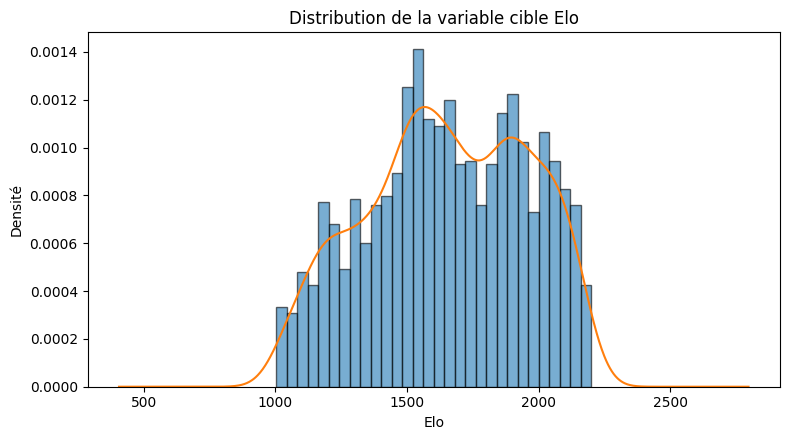

Saved: /content/drive/MyDrive/pmind_eda_outputs/02_elo_distribution_by_cadence.png


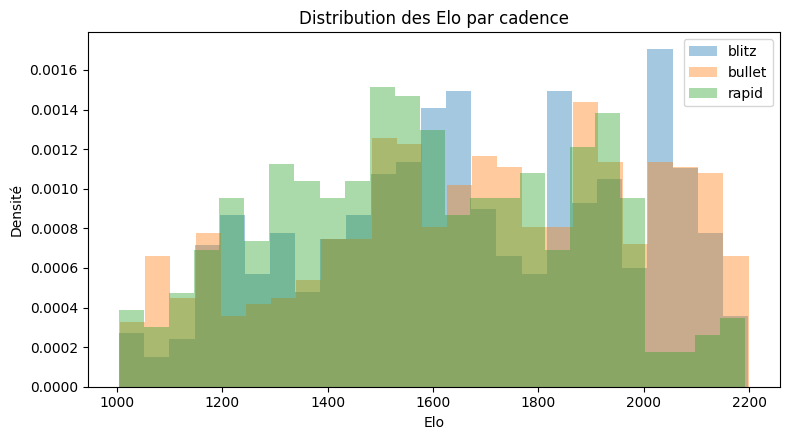

,speed,elo_bucket,n
0,blitz,1000-1400,140
1,blitz,1400-1600,140
2,blitz,1600-1800,140
3,blitz,1800-2000,140
4,blitz,2000-2200,140
5,bullet,1000-1400,140
6,bullet,1400-1600,140
7,bullet,1600-1800,140
8,bullet,1800-2000,140
9,bullet,2000-2200,140


Saved: /content/drive/MyDrive/pmind_eda_outputs/03_elo_bucket_counts_by_cadence.png


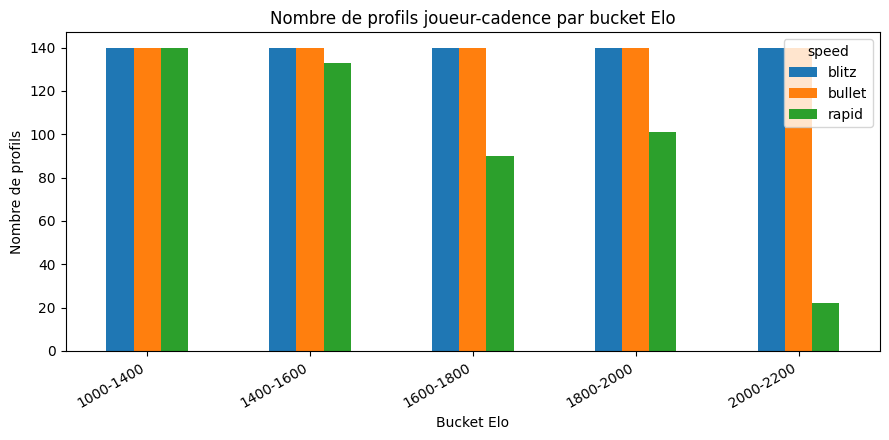

In [ ]:
plt.figure(figsize=(8,4.5))
plt.hist(dfp['elo'], bins=30, density=True, alpha=0.6, edgecolor='black')
try:
    dfp['elo'].plot(kind='kde')
except Exception:
    pass
plt.title('Distribution de la variable cible Elo')
plt.xlabel('Elo')
plt.ylabel('Densité')
savefig('01_target_elo_distribution.png')

# Distribution par cadence
if 'speed' in dfp.columns:
    plt.figure(figsize=(8,4.5))
    for speed, sub in dfp.groupby('speed'):
        plt.hist(sub['elo'], bins=25, alpha=0.4, density=True, label=str(speed))
    plt.title('Distribution des Elo par cadence')
    plt.xlabel('Elo')
    plt.ylabel('Densité')
    plt.legend()
    savefig('02_elo_distribution_by_cadence.png')

# Buckets par cadence
if 'speed' in dfp.columns and 'elo_bucket' in dfp.columns:
    bucket_counts = dfp.groupby(['speed','elo_bucket'], observed=False).size().reset_index(name='n')
    bucket_counts.to_csv(OUT_DIR / 'elo_bucket_counts_by_cadence.csv', index=False)
    display(bucket_counts)
    pivot = bucket_counts.pivot(index='elo_bucket', columns='speed', values='n').fillna(0)
    ax = pivot.plot(kind='bar', figsize=(9,4.5))
    plt.title('Nombre de profils joueur-cadence par bucket Elo')
    plt.xlabel('Bucket Elo')
    plt.ylabel('Nombre de profils')
    plt.xticks(rotation=30, ha='right')
    savefig('03_elo_bucket_counts_by_cadence.png')

**Commentaire rapport.**  
Cette analyse sert à justifier le choix de la régression : `elo` est une variable numérique continue. Les buckets restent utiles pour les analyses stratifiées et la visualisation, mais `elo_bucket` ne doit pas être utilisé comme feature explicative car il est dérivé directement de `elo`.

# Partie B — Analyse univariée et bivariée des features joueur

,feature,missing_rate
0,blunder_low_time_rate_std,0.279958
1,blunder_low_time_rate_median,0.182397
2,blunder_low_time_rate_iqr,0.182397
3,blunder_low_time_rate_mean,0.182397
4,loss_endgame_mean_std,0.002651
5,time_endgame_mean_s_std,0.002651
6,rate_blunder_endgame_std,0.002651
7,rate_blunder_endgame_median,0.000530
8,rate_blunder_endgame_iqr,0.000530
9,loss_endgame_mean_mean,0.000530


Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_loss_mean_mean.png


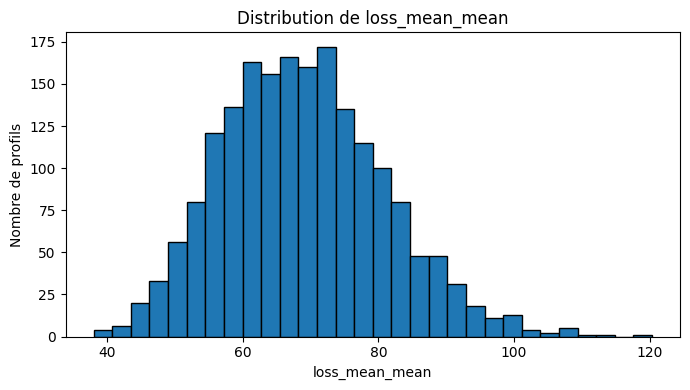

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_loss_median_mean.png


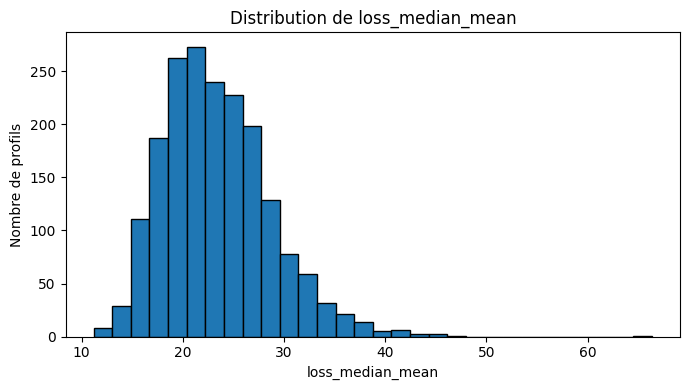

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_loss_p90_mean.png


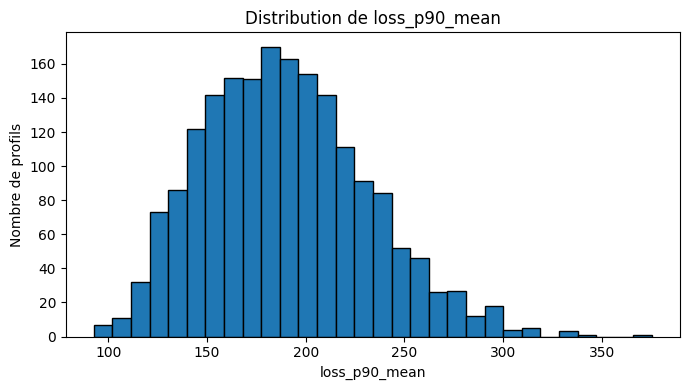

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_loss_max_mean.png


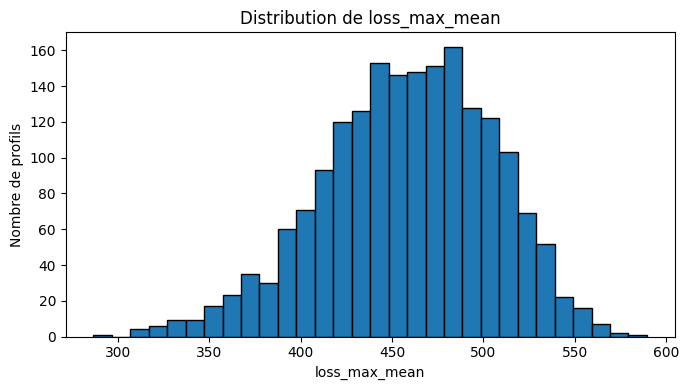

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_rate_blunder_mean.png


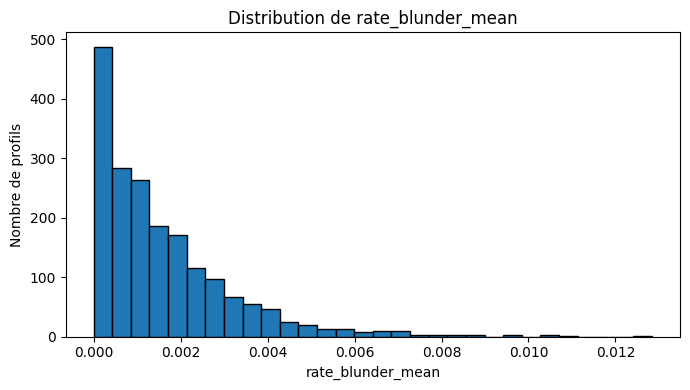

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_rate_error_mean.png


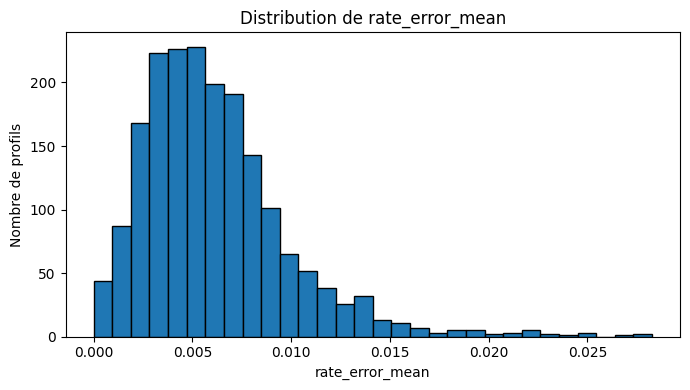

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_rate_mistake_mean.png


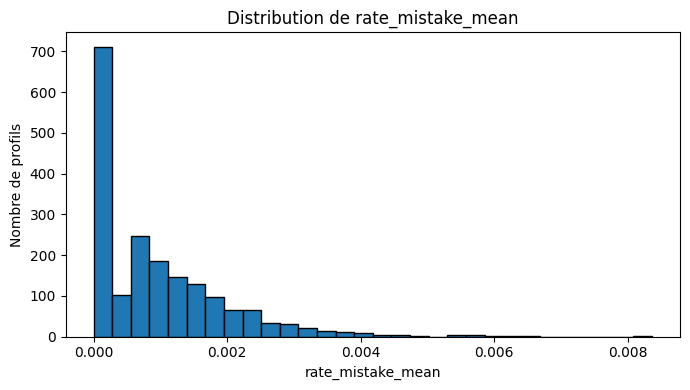

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_time_mean_s_mean.png


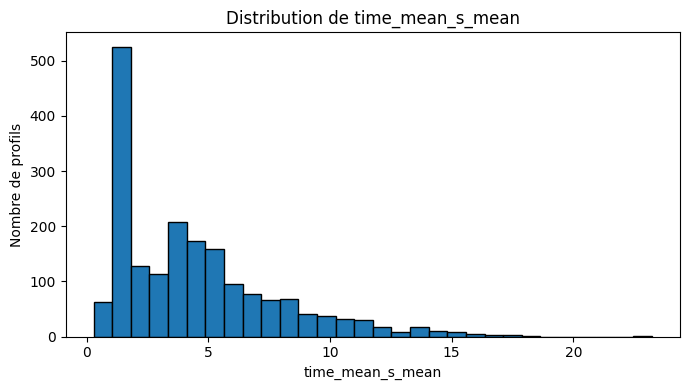

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_clock_mean_s_mean.png


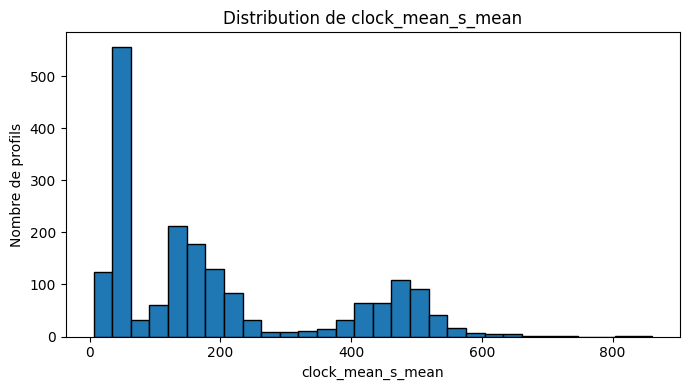

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_win_rate.png


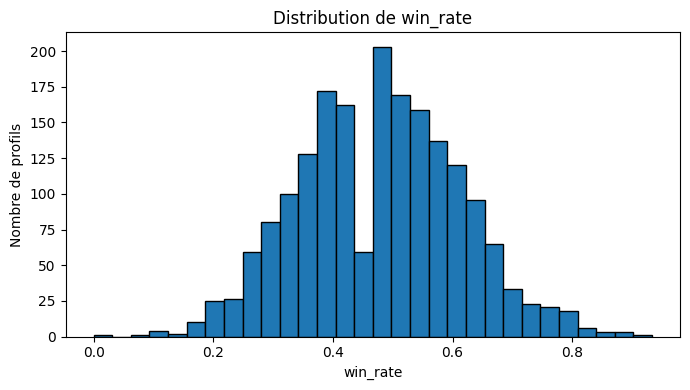

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_eco_diversity.png


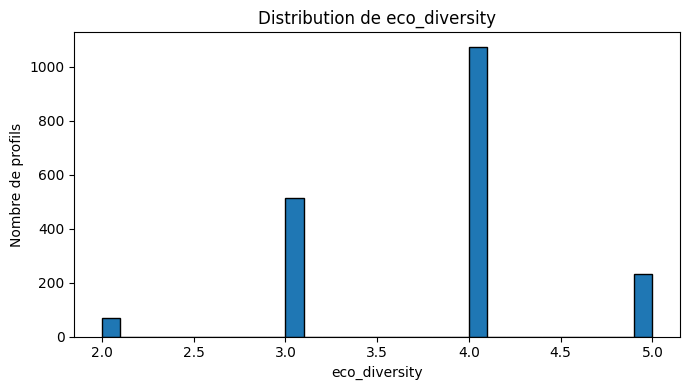

Saved: /content/drive/MyDrive/pmind_eda_outputs/univariate_loss_mean_iqr.png


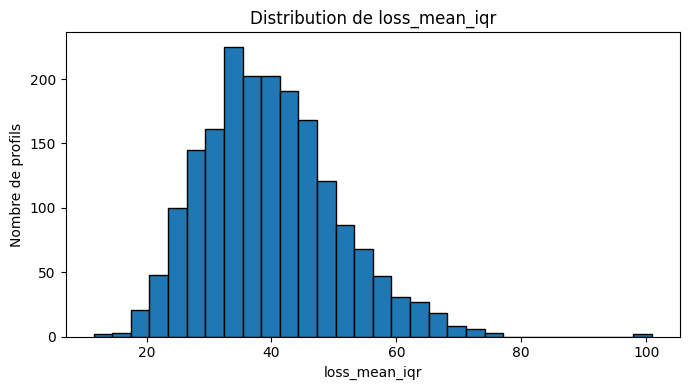

In [ ]:
# Missing values sur player_features
missing = dfp.isna().mean().sort_values(ascending=False).reset_index()
missing.columns = ['feature', 'missing_rate']
missing.to_csv(OUT_DIR / 'missing_values_player_features.csv', index=False)
display(missing.head(25))

# Distributions rapides de quelques features clés
candidate_features = [
    'loss_mean_mean', 'loss_median_mean', 'loss_p90_mean', 'loss_max_mean',
    'rate_blunder_mean', 'rate_error_mean', 'rate_mistake_mean',
    'time_mean_s_mean', 'clock_mean_s_mean', 'win_rate', 'eco_diversity',
    'between_game_loss_variance', 'loss_mean_iqr'
]
features_to_plot = [c for c in candidate_features if c in dfp.columns]

for c in features_to_plot[:12]:
    plt.figure(figsize=(7,4))
    plt.hist(dfp[c].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribution de {c}')
    plt.xlabel(c)
    plt.ylabel('Nombre de profils')
    savefig(f'univariate_{c}.png')

Saved: /content/drive/MyDrive/pmind_eda_outputs/scatter_loss_mean_mean_vs_elo.png


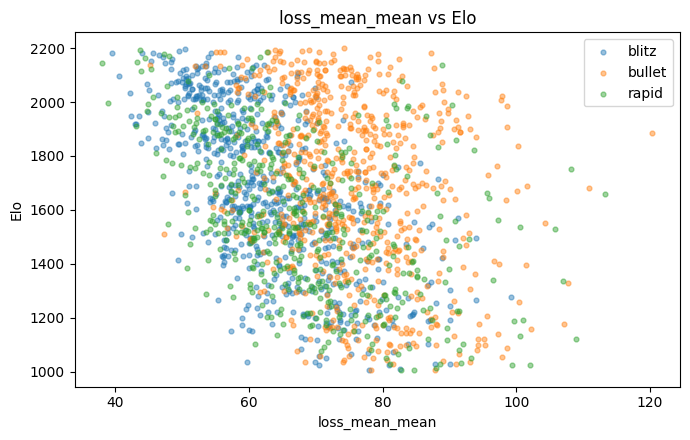

Saved: /content/drive/MyDrive/pmind_eda_outputs/scatter_rate_blunder_mean_vs_elo.png


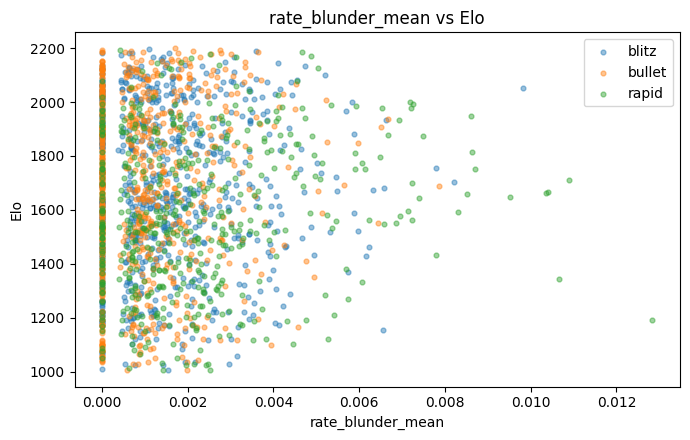

Saved: /content/drive/MyDrive/pmind_eda_outputs/scatter_rate_error_mean_vs_elo.png


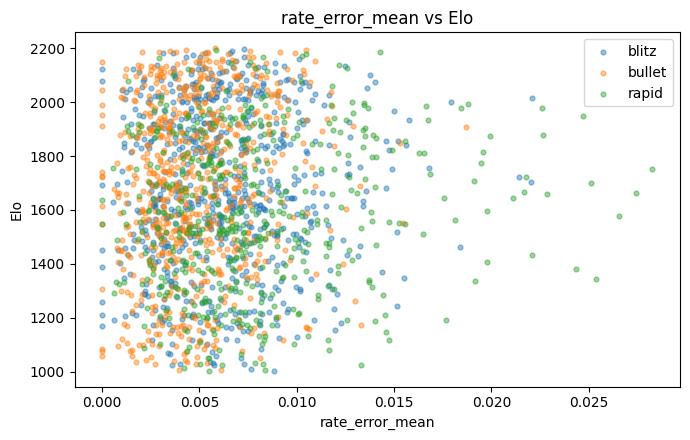

Saved: /content/drive/MyDrive/pmind_eda_outputs/scatter_win_rate_vs_elo.png


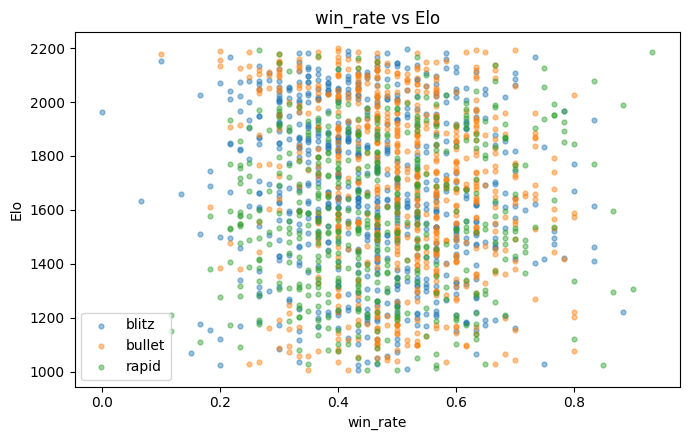

Saved: /content/drive/MyDrive/pmind_eda_outputs/scatter_time_mean_s_mean_vs_elo.png


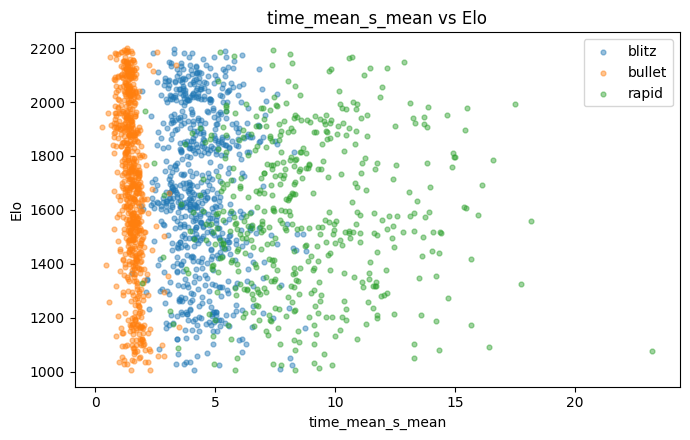

,feature,spearman_corr_with_elo,abs_corr
77,loss_opening_mean_mean,-0.511037,0.511037
78,loss_opening_mean_median,-0.466453,0.466453
79,loss_opening_mean_std,-0.457480,0.457480
80,loss_opening_mean_iqr,-0.433279,0.433279
1,n_moves_median,0.419989,0.419989
0,n_moves_mean,0.412466,0.412466
16,loss_p90_mean,-0.397323,0.397323
4,loss_mean_mean,-0.392378,0.392378
6,loss_mean_std,-0.384458,0.384458
119,loss_when_equal_iqr,-0.370923,0.370923


Saved: /content/drive/MyDrive/pmind_eda_outputs/04_top_spearman_correlations_with_elo.png


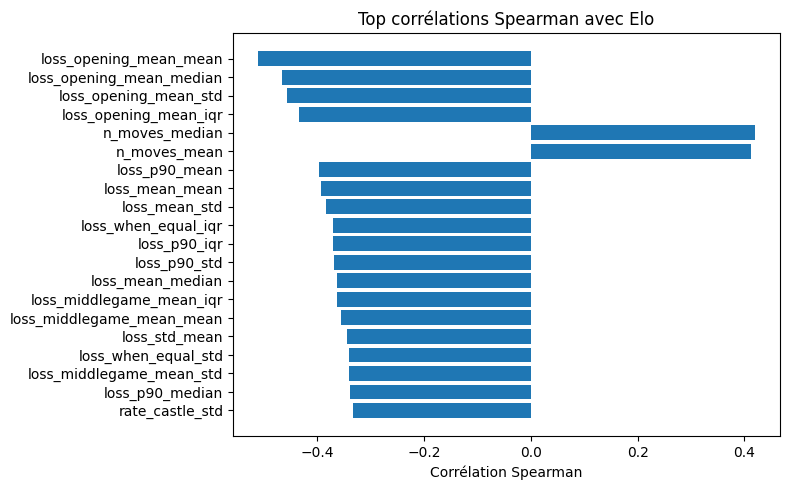

In [ ]:
# Scatter bivarié vs Elo pour les variables importantes disponibles
scatter_candidates = ['loss_mean_mean', 'rate_blunder_mean', 'rate_error_mean', 'win_rate', 'time_mean_s_mean']
for c in [x for x in scatter_candidates if x in dfp.columns]:
    tmp = dfp[[c, 'elo', 'speed']].dropna()
    if len(tmp) > 3000:
        tmp = tmp.sample(3000, random_state=RANDOM_STATE)
    plt.figure(figsize=(7,4.5))
    for sp, sub in tmp.groupby('speed'):
        plt.scatter(sub[c], sub['elo'], s=12, alpha=0.45, label=str(sp))
    plt.title(f'{c} vs Elo')
    plt.xlabel(c)
    plt.ylabel('Elo')
    plt.legend()
    savefig(f'scatter_{c}_vs_elo.png')

# Corrélations Pearson/Spearman des features numériques avec Elo
exclude = ['elo']
num_cols = numeric_cols(dfp, exclude=exclude)
pearson = safe_corr(dfp, num_cols, 'elo', method='pearson')
spearman = safe_corr(dfp, num_cols, 'elo', method='spearman')
pearson.to_csv(OUT_DIR / 'top_pearson_corr_with_elo.csv', index=False)
spearman.to_csv(OUT_DIR / 'top_spearman_corr_with_elo.csv', index=False)
display(spearman.head(20))

plt.figure(figsize=(8,5))
top = spearman.head(20).iloc[::-1]
plt.barh(top['feature'], top['spearman_corr_with_elo'])
plt.title('Top corrélations Spearman avec Elo')
plt.xlabel('Corrélation Spearman')
savefig('04_top_spearman_correlations_with_elo.png')

Saved: /content/drive/MyDrive/pmind_eda_outputs/box_loss_mean_mean_by_elo_bucket.png


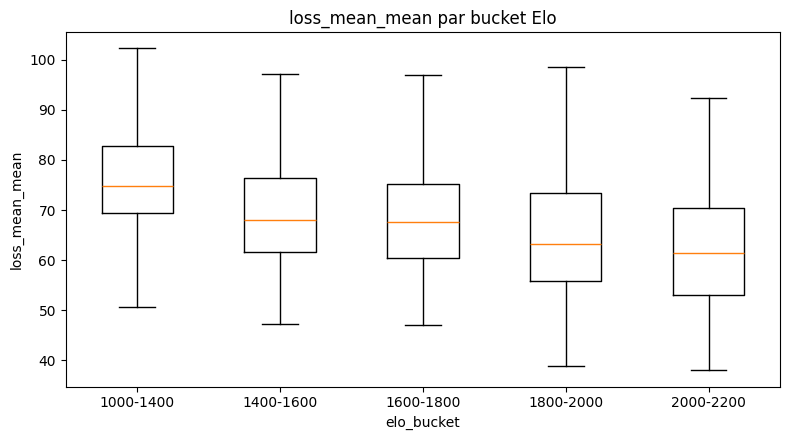

Saved: /content/drive/MyDrive/pmind_eda_outputs/box_rate_blunder_mean_by_elo_bucket.png


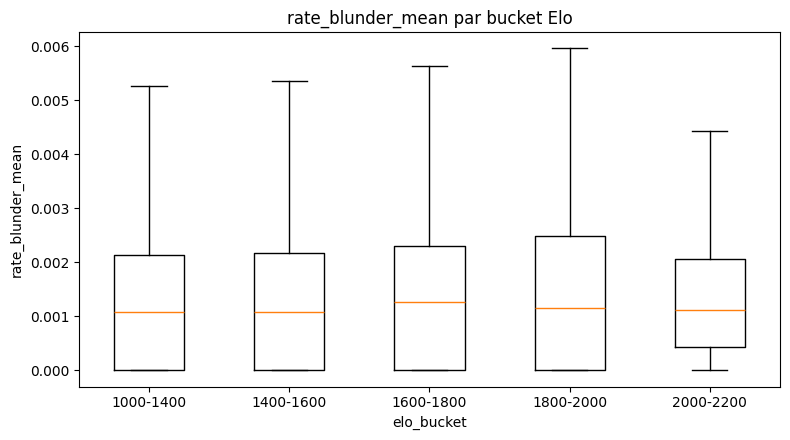

Saved: /content/drive/MyDrive/pmind_eda_outputs/box_rate_error_mean_by_elo_bucket.png


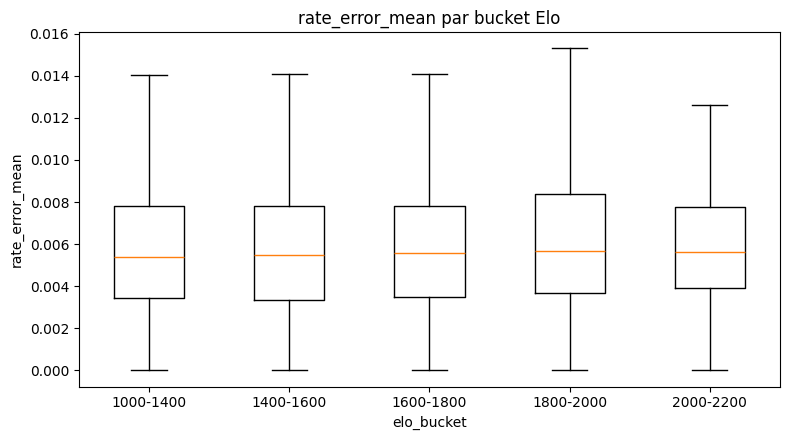

Saved: /content/drive/MyDrive/pmind_eda_outputs/box_win_rate_by_elo_bucket.png


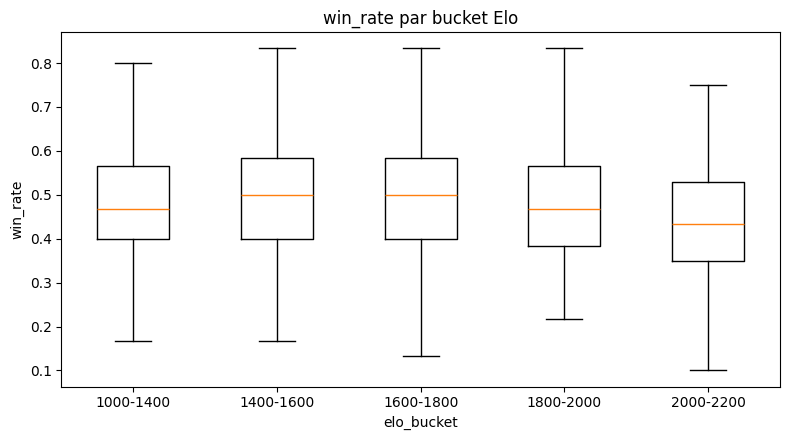

Saved: /content/drive/MyDrive/pmind_eda_outputs/box_time_mean_s_mean_by_elo_bucket.png


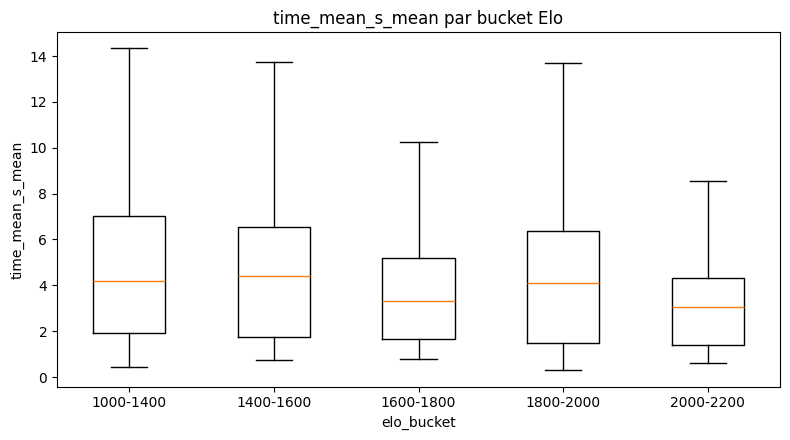

,feature,anova_pvalue,kruskal_pvalue
0,loss_mean_mean,4.868312e-66,4.143789e-63
1,rate_blunder_mean,5.799507e-02,5.992148e-01
2,rate_error_mean,7.694725e-02,4.089023e-01
3,win_rate,3.825984e-06,1.514607e-06
4,time_mean_s_mean,3.743123e-13,2.148273e-17


In [ ]:
# Boxplots stratifiés par bucket Elo pour les features clés
box_features = [c for c in ['loss_mean_mean', 'rate_blunder_mean', 'rate_error_mean', 'win_rate', 'time_mean_s_mean'] if c in dfp.columns]
if 'elo_bucket' in dfp.columns:
    for c in box_features:
        robust_boxplot(dfp, 'elo_bucket', c, f'{c} par bucket Elo', c, f'box_{c}_by_elo_bucket.png')

    # Tests statistiques par bucket : ANOVA et/ou Kruskal-Wallis
    rows = []
    for c in box_features:
        groups = [g[c].dropna().values for _, g in dfp.groupby('elo_bucket', observed=False)]
        groups = [g for g in groups if len(g) > 2]
        row = {'feature': c}
        if SCIPY_AVAILABLE and len(groups) >= 2:
            try:
                row['anova_pvalue'] = stats.f_oneway(*groups).pvalue
            except Exception:
                row['anova_pvalue'] = np.nan
            try:
                row['kruskal_pvalue'] = stats.kruskal(*groups).pvalue
            except Exception:
                row['kruskal_pvalue'] = np.nan
        rows.append(row)
    feature_bucket_tests = pd.DataFrame(rows)
    feature_bucket_tests.to_csv(OUT_DIR / 'feature_bucket_tests.csv', index=False)
    display(feature_bucket_tests)
else:
    print("elo_bucket absent : boxplots/tests par bucket non exécutés.")

# Partie C — Analyse `moves.csv` et `games.csv`

Saved: /content/drive/MyDrive/pmind_eda_outputs/05_cp_loss_clean_distribution.png


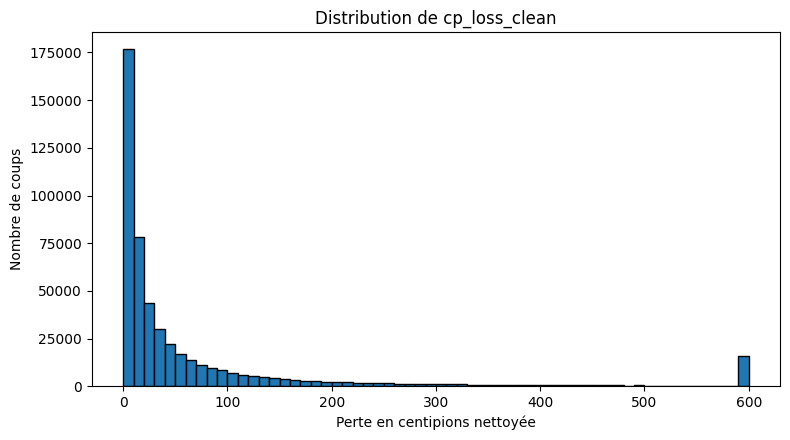

,quality,count
0,is_good,1826428
1,is_inaccuracy,7767
2,is_mistake,2148
3,is_blunder,4130


Saved: /content/drive/MyDrive/pmind_eda_outputs/06_move_quality_counts.png


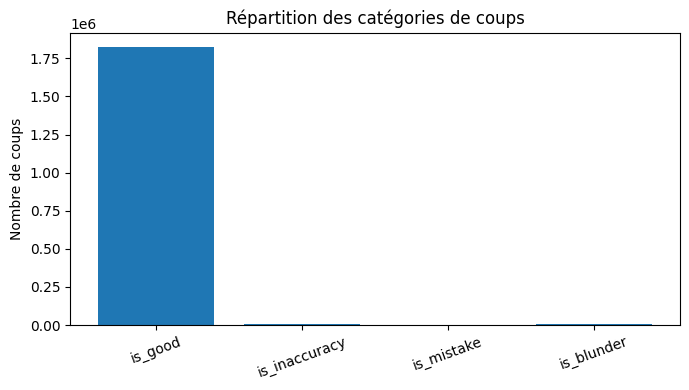

,phase_clean,cp_loss_clean,is_error,is_blunder
0,endgame,80.296516,0.021967,0.008600
1,middlegame,82.185980,0.006771,0.001477
2,opening,38.352091,0.001118,0.000046


Saved: /content/drive/MyDrive/pmind_eda_outputs/07_move_quality_by_phase.png


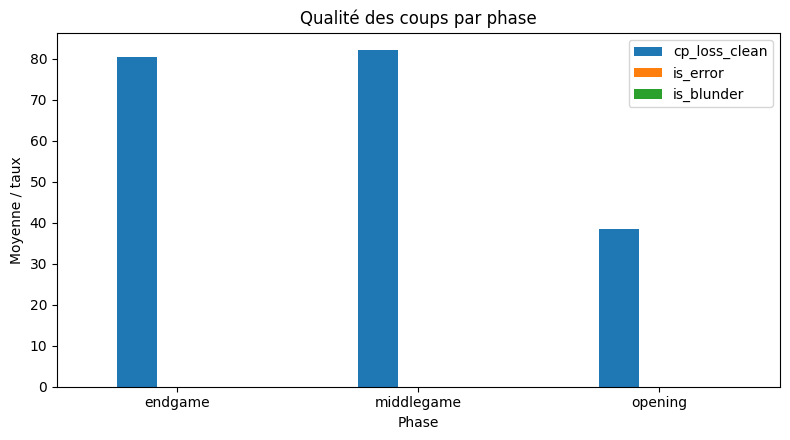

In [ ]:
# Distribution des pertes en centipions
sample_moves = moves_eda.dropna(subset=['cp_loss_clean']).copy()
if len(sample_moves) > 500_000:
    sample_moves = sample_moves.sample(500_000, random_state=RANDOM_STATE)

plt.figure(figsize=(8,4.5))
plt.hist(sample_moves['cp_loss_clean'], bins=60, edgecolor='black')
plt.title('Distribution de cp_loss_clean')
plt.xlabel('Perte en centipions nettoyée')
plt.ylabel('Nombre de coups')
savefig('05_cp_loss_clean_distribution.png')

# Répartition qualité coups
quality_counts = moves_eda[['is_good','is_inaccuracy','is_mistake','is_blunder']].sum().reset_index()
quality_counts.columns = ['quality', 'count']
quality_counts.to_csv(OUT_DIR / 'move_quality_counts.csv', index=False)
display(quality_counts)
plt.figure(figsize=(7,4))
plt.bar(quality_counts['quality'], quality_counts['count'])
plt.title('Répartition des catégories de coups')
plt.ylabel('Nombre de coups')
plt.xticks(rotation=20)
savefig('06_move_quality_counts.png')

# Qualité par phase
phase_quality = moves_eda.groupby('phase_clean')[['cp_loss_clean','is_error','is_blunder']].mean().reset_index()
phase_quality.to_csv(OUT_DIR / 'move_quality_by_phase.csv', index=False)
display(phase_quality)
phase_quality.plot(x='phase_clean', y=['cp_loss_clean','is_error','is_blunder'], kind='bar', figsize=(8,4.5))
plt.title('Qualité des coups par phase')
plt.xlabel('Phase')
plt.ylabel('Moyenne / taux')
plt.xticks(rotation=0)
savefig('07_move_quality_by_phase.png')

Saved: /content/drive/MyDrive/pmind_eda_outputs/08_time_spent_vs_cp_loss.png


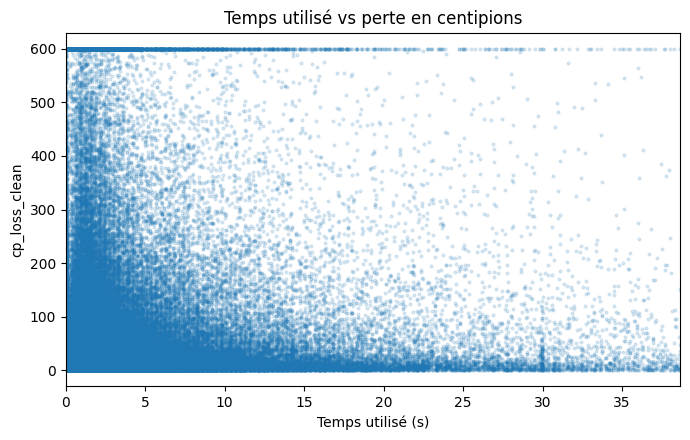

,speed,zero_time_rate
0,blitz,0.122060
1,bullet,0.158836
2,rapid,0.118550


Saved: /content/drive/MyDrive/pmind_eda_outputs/09_zero_time_rate_by_cadence.png


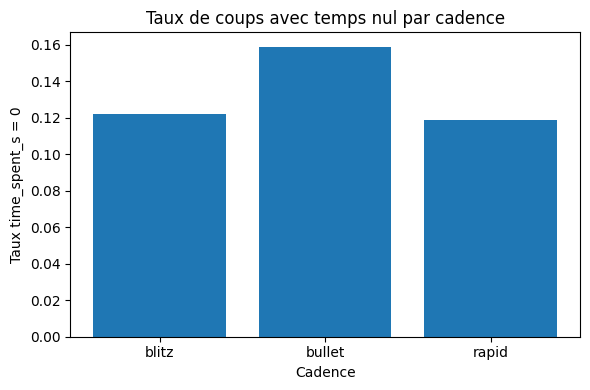

,speed,clock_bin,is_blunder,is_error,cp_loss_clean
0,blitz,très bas,0.009423,0.023825,93.029945
1,blitz,bas,0.005862,0.018689,87.766778
2,blitz,moyen,0.002159,0.008178,70.601747
3,blitz,haut,0.000360,0.002519,45.680432
4,blitz,très haut,0.000000,0.006313,58.834596


In [ ]:
# Temps vs cp_loss
if 'time_spent_s' in moves_eda.columns:
    tmp = moves_eda[['time_spent_s','cp_loss_clean','speed','clock_before_s','is_blunder','is_good']].dropna(subset=['time_spent_s','cp_loss_clean'])
    if len(tmp) > 150_000:
        tmp = tmp.sample(150_000, random_state=RANDOM_STATE)
    plt.figure(figsize=(7,4.5))
    plt.scatter(tmp['time_spent_s'], tmp['cp_loss_clean'], s=4, alpha=0.15)
    plt.xlim(0, tmp['time_spent_s'].quantile(0.99))
    plt.title('Temps utilisé vs perte en centipions')
    plt.xlabel('Temps utilisé (s)')
    plt.ylabel('cp_loss_clean')
    savefig('08_time_spent_vs_cp_loss.png')

    # Zéro time / premove-like par cadence
    zero_time = moves_eda.assign(zero_time=(moves_eda['time_spent_s'] <= 0)).groupby('speed')['zero_time'].mean().reset_index(name='zero_time_rate')
    zero_time.to_csv(OUT_DIR / 'zero_time_rate_by_cadence.csv', index=False)
    display(zero_time)
    plt.figure(figsize=(6,4))
    plt.bar(zero_time['speed'], zero_time['zero_time_rate'])
    plt.title('Taux de coups avec temps nul par cadence')
    plt.xlabel('Cadence')
    plt.ylabel('Taux time_spent_s = 0')
    savefig('09_zero_time_rate_by_cadence.png')

# Clock before vs qualité
if 'clock_before_s' in moves_eda.columns:
    bins = pd.qcut(moves_eda['clock_before_s'].rank(method='first'), 5, labels=['très bas','bas','moyen','haut','très haut'])
    clock_quality = moves_eda.assign(clock_bin=bins).groupby(['speed','clock_bin'])[['is_blunder','is_error','cp_loss_clean']].mean().reset_index()
    clock_quality.to_csv(OUT_DIR / 'clock_quality_by_cadence.csv', index=False)
    display(clock_quality.head())

In [ ]:
# Contexte parties : résultats, couleurs, elo diff
if len(games):
    # speed proportions
    speed_counts = games.groupby('speed').size().reset_index(name='n_games')
    speed_counts['prop'] = speed_counts['n_games'] / speed_counts['n_games'].sum()
    speed_counts.to_csv(OUT_DIR / 'game_speed_proportions.csv', index=False)
    display(speed_counts)

    # win rate white/black si colonnes disponibles
    if 'target_color' in games.columns and 'target_score' in games.columns:
        color_wr = games.groupby(['speed','target_color'])['target_score'].mean().reset_index(name='score_mean')
        color_wr.to_csv(OUT_DIR / 'target_score_by_color_speed.csv', index=False)
        display(color_wr)

    # elo_diff vs result si possible
    elo_diff_col = find_col(games, ['target_elo_diff', 'elo_diff'])
    if elo_diff_col and 'target_score' in games.columns:
        tmp = games[[elo_diff_col,'target_score','speed']].dropna()
        if len(tmp) > 5000:
            tmp = tmp.sample(5000, random_state=RANDOM_STATE)
        plt.figure(figsize=(7,4.5))
        plt.scatter(tmp[elo_diff_col], tmp['target_score'], s=8, alpha=0.25)
        plt.title('Différence Elo vs résultat du joueur cible')
        plt.xlabel(elo_diff_col)
        plt.ylabel('target_score')
        savefig('10_elo_diff_vs_target_score.png')

    # ouvertures vs niveau : eco family moyen elo
    if 'opening_eco' in games.columns and 'target_elo' in games.columns:
        games_tmp = games.copy()
        games_tmp['eco_family'] = games_tmp['opening_eco'].astype(str).str[0]
        eco_elo = games_tmp.groupby('eco_family')['target_elo'].agg(['count','mean','median']).reset_index().sort_values('count', ascending=False)
        eco_elo.to_csv(OUT_DIR / 'opening_eco_family_elo_summary.csv', index=False)
        display(eco_elo.head(10))

,speed,n_games,prop
0,blitz,21000,0.371156
1,bullet,21000,0.371156
2,rapid,14580,0.257688


,speed,target_color,score_mean
0,blitz,black,0.442719
1,blitz,white,0.471355
2,bullet,black,0.496103
3,bullet,white,0.511166
4,rapid,black,0.448984
5,rapid,white,0.485308


,eco_family,count,mean,median
2,C,16713,1584.090768,1575.0
1,B,16184,1681.379016,1696.0
0,A,15219,1690.459689,1703.0
3,D,7645,1652.626292,1647.0
4,E,819,1784.470085,1819.0


# Partie D — Séparation par cadence : tests et justification

Saved: /content/drive/MyDrive/pmind_eda_outputs/cadence_box_loss_mean_mean.png


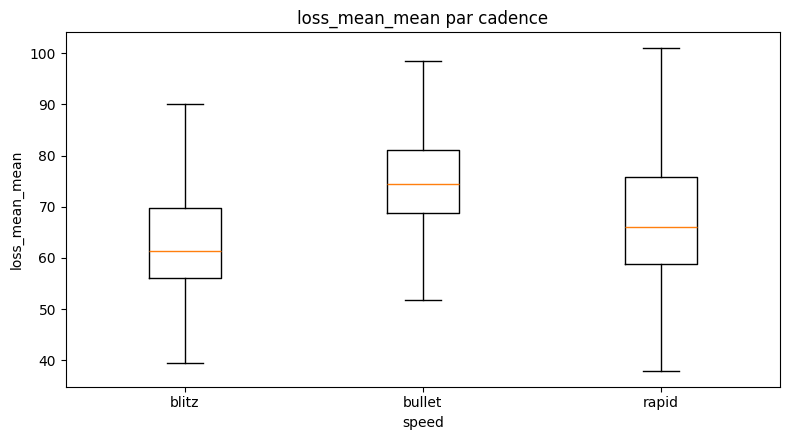

Saved: /content/drive/MyDrive/pmind_eda_outputs/cadence_box_rate_blunder_mean.png


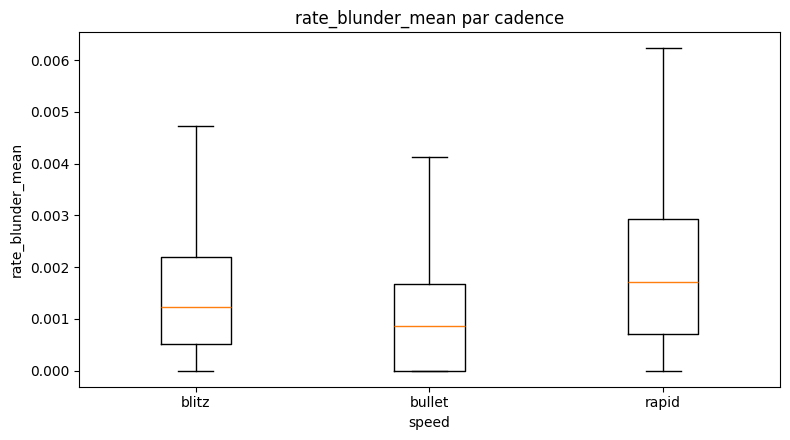

Saved: /content/drive/MyDrive/pmind_eda_outputs/cadence_box_rate_error_mean.png


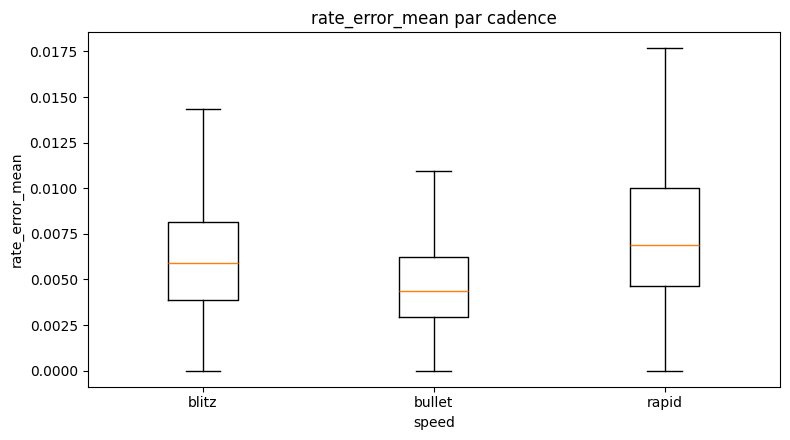

Saved: /content/drive/MyDrive/pmind_eda_outputs/cadence_box_time_mean_s_mean.png


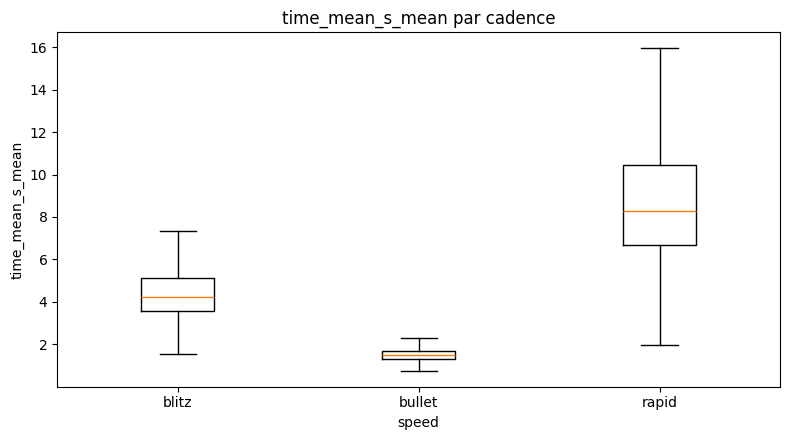

Saved: /content/drive/MyDrive/pmind_eda_outputs/cadence_box_n_moves_mean.png


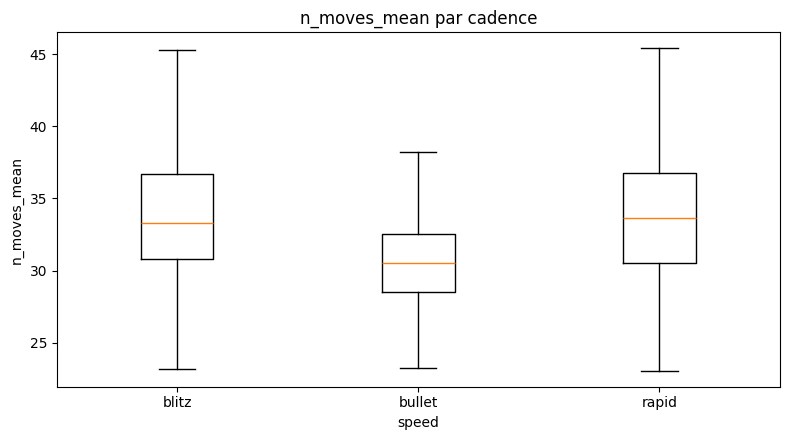

,feature,anova_pvalue,kruskal_pvalue
0,loss_mean_mean,7.427278e-89,1.140183e-89
1,rate_blunder_mean,2.606813e-30,2.891154e-25
2,rate_error_mean,4.840348e-45,4.400254e-38
3,time_mean_s_mean,0.000000e+00,0.000000e+00
4,n_moves_mean,1.163126e-64,1.169772e-60


In [ ]:
# Boxplots cadence : loss, blunder, time
cadence_features = [c for c in ['loss_mean_mean','rate_blunder_mean','rate_error_mean','time_mean_s_mean','n_moves_mean'] if c in dfp.columns]
if 'speed' in dfp.columns:
    for c in cadence_features:
        robust_boxplot(dfp, 'speed', c, f'{c} par cadence', c, f'cadence_box_{c}.png')

    # Tests statistiques entre cadences
    rows=[]
    for c in cadence_features:
        groups = [g[c].dropna().values for _, g in dfp.groupby('speed')]
        groups = [g for g in groups if len(g)>2]
        row={'feature': c}
        if SCIPY_AVAILABLE and len(groups)>=2:
            try: row['anova_pvalue'] = stats.f_oneway(*groups).pvalue
            except Exception: row['anova_pvalue'] = np.nan
            try: row['kruskal_pvalue'] = stats.kruskal(*groups).pvalue
            except Exception: row['kruskal_pvalue'] = np.nan
        rows.append(row)
    cadence_tests = pd.DataFrame(rows)
    cadence_tests.to_csv(OUT_DIR / 'cadence_difference_tests.csv', index=False)
    display(cadence_tests)
else:
    print('Colonne speed absente : comparaison par cadence non exécutée.')

# Partie E — Features de qualité, contexte de l’erreur, phases, stabilité

,speed,phase_clean,cp_loss_clean
0,blitz,endgame,76.863013
1,blitz,middlegame,75.333428
2,blitz,opening,33.685741
3,bullet,endgame,88.743479
4,bullet,middlegame,90.595397
5,bullet,opening,43.125996
6,rapid,endgame,77.038597
7,rapid,middlegame,80.727985
8,rapid,opening,38.265093


Saved: /content/drive/MyDrive/pmind_eda_outputs/11_cp_loss_by_phase_and_cadence.png


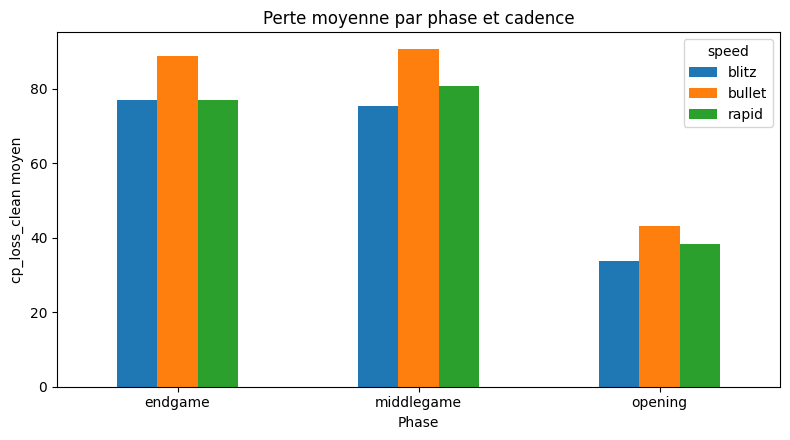

,feature,spearman_corr_with_elo,abs_corr
7,loss_when_equal_iqr,-0.370923,0.370923
6,loss_when_equal_std,-0.340935,0.340935
4,loss_when_equal_mean,-0.303826,0.303826
5,loss_when_equal_median,-0.222216,0.222216
11,loss_when_losing_median,-0.210414,0.210414
10,loss_when_losing_mean,-0.169505,0.169505
0,loss_when_winning_mean,-0.134651,0.134651
1,loss_when_winning_median,-0.127971,0.127971
13,loss_when_losing_iqr,-0.126875,0.126875
3,loss_when_winning_iqr,-0.088923,0.088923


,feature,spearman_corr_with_elo,abs_corr
44,loss_opening_mean_std,-0.457480,0.457480
45,loss_opening_mean_iqr,-0.433279,0.433279
2,loss_mean_std,-0.384458,0.384458
65,loss_when_equal_iqr,-0.370923,0.370923
11,loss_p90_iqr,-0.369955,0.369955
10,loss_p90_std,-0.368589,0.368589
50,loss_middlegame_mean_iqr,-0.363702,0.363702
6,loss_std_mean,-0.345015,0.345015
64,loss_when_equal_std,-0.340935,0.340935
49,loss_middlegame_mean_std,-0.340092,0.340092


Saved: /content/drive/MyDrive/pmind_eda_outputs/12_loss_mean_vs_dispersion.png


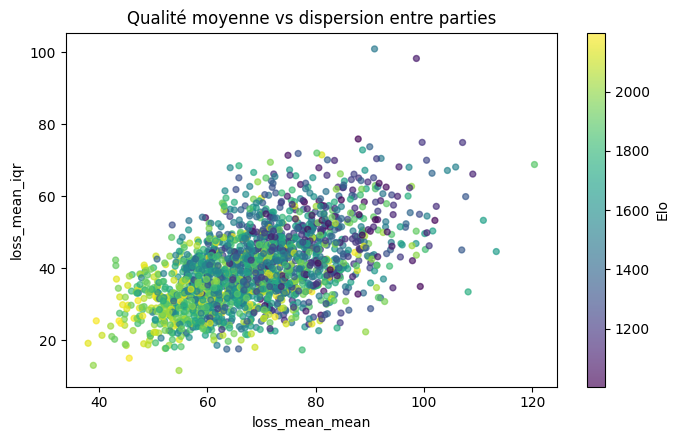

In [ ]:
# cp_loss par phase et cadence
if len(moves_eda):
    phase_speed = moves_eda.groupby(['speed','phase_clean'])['cp_loss_clean'].mean().reset_index()
    phase_speed.to_csv(OUT_DIR / 'cp_loss_by_phase_and_cadence.csv', index=False)
    display(phase_speed)
    piv = phase_speed.pivot(index='phase_clean', columns='speed', values='cp_loss_clean')
    ax = piv.plot(kind='bar', figsize=(8,4.5))
    plt.title('Perte moyenne par phase et cadence')
    plt.xlabel('Phase')
    plt.ylabel('cp_loss_clean moyen')
    plt.xticks(rotation=0)
    savefig('11_cp_loss_by_phase_and_cadence.png')

# Contexte de l'erreur vs Elo : corrélations si features dispo
context_features = [c for c in dfp.columns if any(k in c for k in ['loss_when_winning','loss_when_equal','loss_when_losing','rate_blunder_when_equal'])]
context_corr = safe_corr(dfp, context_features, 'elo', method='spearman')
context_corr.to_csv(OUT_DIR / 'context_error_corr_with_elo.csv', index=False)
display(context_corr.head(15))

# Stabilité inter-parties : corrélation avec Elo
stability_candidates = [c for c in dfp.columns if any(k in c for k in ['_std','_iqr','variance','_cv','prop_games_with'])]
stability_corr = safe_corr(dfp, stability_candidates, 'elo', method='spearman')
stability_corr.to_csv(OUT_DIR / 'stability_corr_with_elo.csv', index=False)
display(stability_corr.head(20))

# loss_mean vs dispersion
x_col = 'loss_mean_mean'
y_col = 'loss_mean_iqr' if 'loss_mean_iqr' in dfp.columns else ('loss_mean_std' if 'loss_mean_std' in dfp.columns else None)
if x_col in dfp.columns and y_col:
    tmp = dfp[[x_col,y_col,'elo','speed']].dropna()
    plt.figure(figsize=(7,4.5))
    sc = plt.scatter(tmp[x_col], tmp[y_col], c=tmp['elo'], s=18, alpha=0.65)
    plt.colorbar(sc, label='Elo')
    plt.title('Qualité moyenne vs dispersion entre parties')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    savefig('12_loss_mean_vs_dispersion.png')

# Partie F — Multicolinéarité, redondance et leakage

Saved: /content/drive/MyDrive/pmind_eda_outputs/13_feature_correlation_heatmap.png


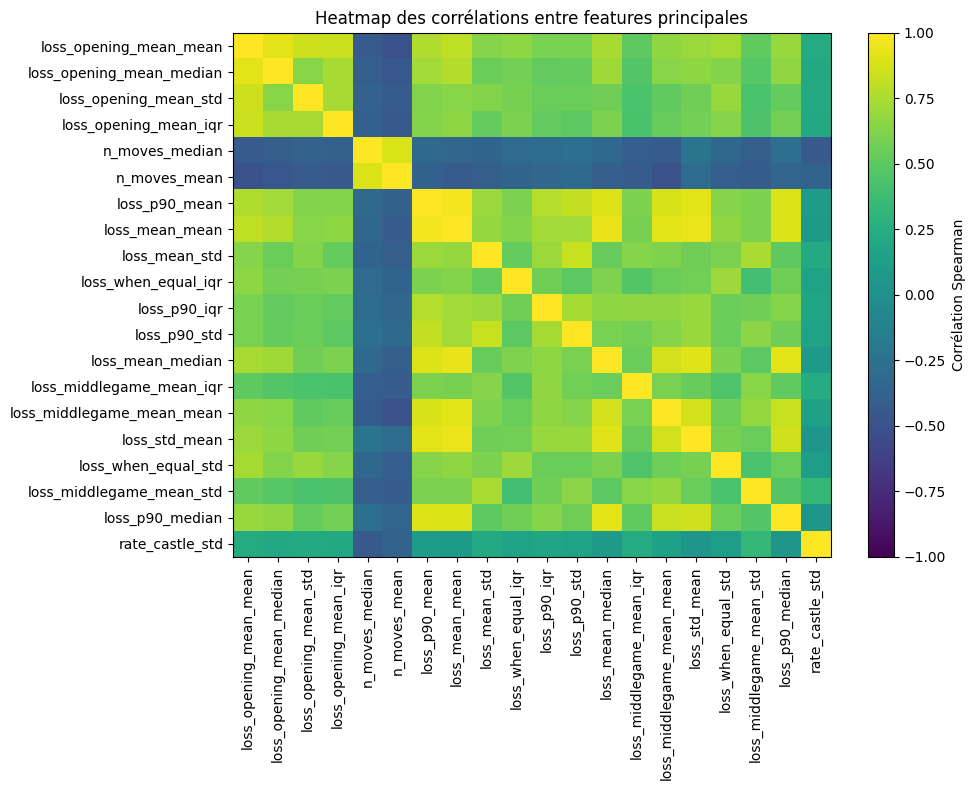

,feature_1,feature_2,abs_spearman_corr
3468,rate_good_iqr,rate_error_iqr,1.000000
3237,rate_good_median,rate_error_median,1.000000
9780,rate_blunder_when_equal_mean,rate_blunder_when_equal_std,1.000000
3120,rate_good_mean,rate_error_mean,1.000000
3353,rate_good_std,rate_error_std,1.000000
8181,rate_blunder_opening_mean,rate_blunder_opening_std,0.999999
4452,rate_blunder_iqr,n_blunders_iqr,0.999999
8736,rate_blunder_middlegame_mean,rate_blunder_middlegame_std,0.996008
9891,rate_blunder_when_losing_mean,rate_blunder_when_losing_std,0.995131
9605,rate_blunder_when_winning_mean,rate_blunder_when_winning_std,0.995003


,feature,VIF
7,loss_mean_mean,53.221097
6,loss_p90_mean,37.072024
0,loss_opening_mean_mean,33.818301
1,loss_opening_mean_median,12.538378
12,loss_mean_median,11.643444
14,loss_middlegame_mean_mean,10.018455
11,loss_p90_std,7.113652
2,loss_opening_mean_std,6.812130
5,n_moves_mean,5.928340
8,loss_mean_std,5.529229


⚠ Leakage : elo_bucket est dérivé de elo. Il doit être exclu des features de prédiction.


In [ ]:
# Préparer matrice numérique en excluant leakage / identifiants
leakage_cols = {'elo', 'elo_bucket', 'target_name', 'username', 'game_id'}
num = dfp.select_dtypes(include=[np.number]).replace([np.inf,-np.inf], np.nan)
num = num[[c for c in num.columns if c not in leakage_cols]]
# Supprimer colonnes trop manquantes / constantes
num = num.loc[:, num.isna().mean() < 0.4]
num = num.loc[:, num.nunique(dropna=True) > 1]
num_imp = num.fillna(num.median(numeric_only=True))

# Top features corrélées avec elo pour heatmap lisible
top_features = spearman.head(25)['feature'].tolist()
top_features = [c for c in top_features if c in num_imp.columns]
heat_cols = top_features[:20]
if len(heat_cols) >= 2:
    corr_mat = num_imp[heat_cols].corr(method='spearman')
    corr_mat.to_csv(OUT_DIR / 'feature_correlation_heatmap_matrix.csv')
    plt.figure(figsize=(10,8))
    im = plt.imshow(corr_mat.values, aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(im, label='Corrélation Spearman')
    plt.xticks(range(len(heat_cols)), heat_cols, rotation=90)
    plt.yticks(range(len(heat_cols)), heat_cols)
    plt.title('Heatmap des corrélations entre features principales')
    savefig('13_feature_correlation_heatmap.png')

# Paires redondantes corr > 0.90
corr_all = num_imp.corr(method='spearman').abs()
upper = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ['feature_1','feature_2','abs_spearman_corr']
pairs = pairs[pairs['abs_spearman_corr'] >= 0.90].sort_values('abs_spearman_corr', ascending=False)
pairs.to_csv(OUT_DIR / 'highly_correlated_feature_pairs.csv', index=False)
display(pairs.head(30))

# VIF sur sous-ensemble de top features pour éviter explosion
if STATSMODELS_AVAILABLE and len(top_features) >= 2:
    vif_cols = top_features[:15]
    X = num_imp[vif_cols].copy()
    # Standardisation
    X = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
    X = X.dropna(axis=1)
    vif_rows=[]
    for i, c in enumerate(X.columns):
        try:
            vif_rows.append({'feature': c, 'VIF': variance_inflation_factor(X.values, i)})
        except Exception:
            vif_rows.append({'feature': c, 'VIF': np.nan})
    vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
else:
    vif_df = pd.DataFrame({'feature': [], 'VIF': []})

vif_df.to_csv(OUT_DIR / 'vif_top_features.csv', index=False)
display(vif_df)

print('⚠ Leakage : elo_bucket est dérivé de elo. Il doit être exclu des features de prédiction.')

# Partie G — Few-shot EDA : effet du nombre de parties

,n_games,rep,feature,mae_vs_full,median_abs_error_vs_full,n_players
0,3,0,loss_mean,14.294971,11.510408,1886
1,3,0,loss_median,6.409933,4.675000,1886
2,3,0,loss_p90,55.173604,45.663333,1886
3,3,0,rate_blunder,0.002127,0.001209,1886
4,3,0,rate_error,0.006186,0.005059,1886


Saved: /content/drive/MyDrive/pmind_eda_outputs/14_fewshot_feature_stability.png


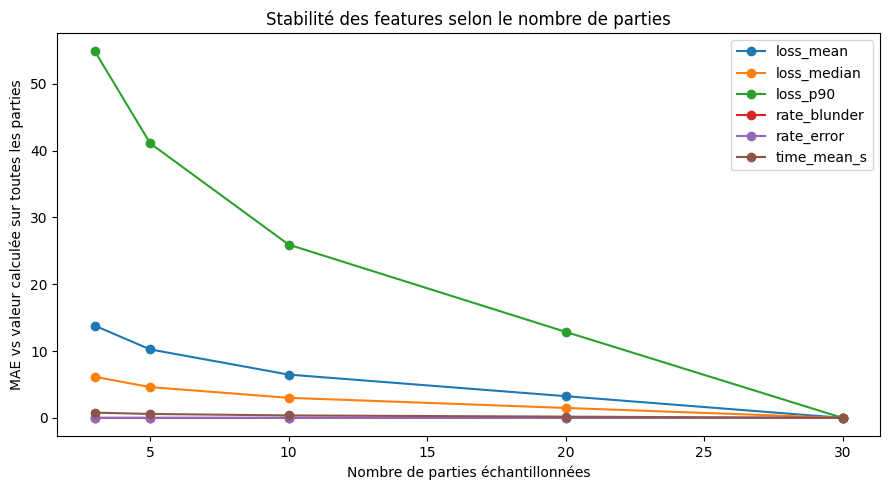

In [ ]:
# Analyse de convergence des features selon n_games.
# On compare les features calculées sur n parties à la valeur de référence calculée sur toutes les parties disponibles.

fewshot_game_cols = [c for c in ['loss_mean','loss_median','loss_p90','rate_blunder','rate_error','time_mean_s','good_fast_move_rate','blunder_low_time_rate'] if c in game_features.columns]
keys = ['speed', 'target_name']
keys = [k for k in keys if k in game_features.columns]
N_VALUES = [3, 5, 10, 20, 30]
REPS = 10

if len(fewshot_game_cols) == 0 or len(keys) == 0:
    print('Few-shot EDA non exécutée : colonnes game-level ou clés joueur absentes.')
    fewshot = pd.DataFrame()
else:
    # Référence full par joueur
    full_ref = game_features.groupby(keys, dropna=False)[fewshot_game_cols].mean().reset_index()
    full_ref = full_ref.rename(columns={c: f'{c}_full' for c in fewshot_game_cols})

    rows=[]
    grouped = list(game_features.groupby(keys, dropna=False))
    for n in N_VALUES:
        for rep in range(REPS):
            sampled_parts=[]
            for k, sub in grouped:
                if len(sub) < n:
                    continue
                sampled_parts.append(sub.sample(n=n, replace=False, random_state=RANDOM_STATE + rep * 100 + n))
            if not sampled_parts:
                continue
            sampled = pd.concat(sampled_parts, ignore_index=True)
            agg = sampled.groupby(keys, dropna=False)[fewshot_game_cols].mean().reset_index()
            merged = agg.merge(full_ref, on=keys, how='inner')
            for c in fewshot_game_cols:
                err = (merged[c] - merged[f'{c}_full']).abs()
                rows.append({'n_games': n, 'rep': rep, 'feature': c, 'mae_vs_full': err.mean(), 'median_abs_error_vs_full': err.median(), 'n_players': len(merged)})

    fewshot = pd.DataFrame(rows)
    fewshot.to_csv(OUT_DIR / 'fewshot_feature_stability.csv', index=False)
    display(fewshot.head())

    # Courbe de convergence pour quelques features
    if len(fewshot):
        plt.figure(figsize=(9,5))
        for c in fewshot_game_cols[:6]:
            sub = fewshot[fewshot['feature'] == c].groupby('n_games')['mae_vs_full'].mean().reset_index()
            plt.plot(sub['n_games'], sub['mae_vs_full'], marker='o', label=c)
        plt.title('Stabilité des features selon le nombre de parties')
        plt.xlabel('Nombre de parties échantillonnées')
        plt.ylabel('MAE vs valeur calculée sur toutes les parties')
        plt.legend()
        savefig('14_fewshot_feature_stability.png')

,mean_mae_vs_full_mean,median_mae_vs_full_median
n_games,,
3,1.383685e+01,15.638056
5,1.023549e+01,11.923738
10,6.479789e+00,7.557369
20,3.261205e+00,3.775235
30,6.061841e-16,0.000000


Saved: /content/drive/MyDrive/pmind_eda_outputs/15_fewshot_mean_vs_median.png


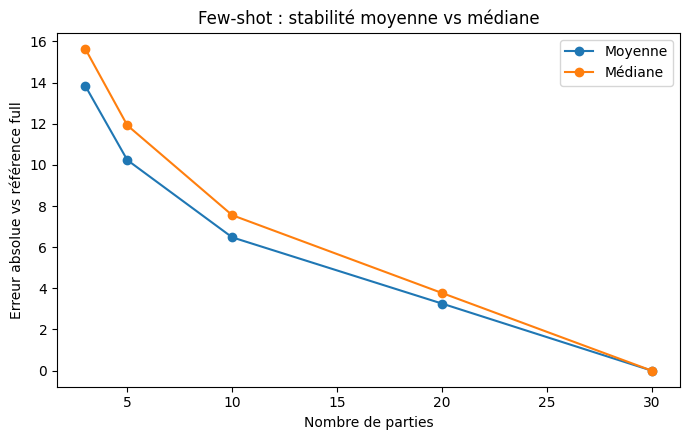

In [ ]:
# Comparaison moyenne vs médiane pour la stabilité de loss_mean selon n_games
if 'loss_mean' in game_features.columns and len(keys) > 0:
    rows=[]
    full_mean = game_features.groupby(keys, dropna=False)['loss_mean'].mean().reset_index(name='full_mean')
    full_median = game_features.groupby(keys, dropna=False)['loss_mean'].median().reset_index(name='full_median')
    ref = full_mean.merge(full_median, on=keys)
    grouped = list(game_features.groupby(keys, dropna=False))
    for n in N_VALUES:
        for rep in range(REPS):
            sampled_parts=[]
            for k, sub in grouped:
                if len(sub) < n:
                    continue
                sampled_parts.append(sub.sample(n=n, replace=False, random_state=1000 + rep * 100 + n))
            if not sampled_parts:
                continue
            sampled = pd.concat(sampled_parts, ignore_index=True)
            agg = sampled.groupby(keys, dropna=False)['loss_mean'].agg(sample_mean='mean', sample_median='median').reset_index()
            merged = agg.merge(ref, on=keys, how='inner')
            rows.append({
                'n_games': n,
                'rep': rep,
                'mean_mae_vs_full_mean': (merged['sample_mean'] - merged['full_mean']).abs().mean(),
                'median_mae_vs_full_median': (merged['sample_median'] - merged['full_median']).abs().mean(),
                'n_players': len(merged)
            })
    medmean = pd.DataFrame(rows)
    medmean.to_csv(OUT_DIR / 'fewshot_mean_vs_median_loss_stability.csv', index=False)
    if len(medmean):
        display(medmean.groupby('n_games')[['mean_mae_vs_full_mean','median_mae_vs_full_median']].mean())
        plt.figure(figsize=(7,4.5))
        plotdf = medmean.groupby('n_games')[['mean_mae_vs_full_mean','median_mae_vs_full_median']].mean().reset_index()
        plt.plot(plotdf['n_games'], plotdf['mean_mae_vs_full_mean'], marker='o', label='Moyenne')
        plt.plot(plotdf['n_games'], plotdf['median_mae_vs_full_median'], marker='o', label='Médiane')
        plt.title('Few-shot : stabilité moyenne vs médiane')
        plt.xlabel('Nombre de parties')
        plt.ylabel('Erreur absolue vs référence full')
        plt.legend()
        savefig('15_fewshot_mean_vs_median.png')
else:
    print('Comparaison moyenne/médiane non exécutée : loss_mean ou clés joueur absentes.')

# Partie H — Tableau de synthèse pour le rapport

In [ ]:
# Création d'un petit rapport CSV avec les fichiers produits
outputs = sorted([p.name for p in OUT_DIR.glob('*')])
out_df = pd.DataFrame({'output_file': outputs})
out_df.to_csv(OUT_DIR / 'eda_outputs_index.csv', index=False)
display(out_df)
print('Tous les résultats sont dans :', OUT_DIR)

,output_file
0,01_elo_distribution_by_cadence.png
1,01_target_elo_distribution.png
2,02_elo_bucket_counts.png
3,02_elo_distribution_by_cadence.png
4,03_elo_bucket_counts_by_cadence.png
...,...
91,univariate_rate_mistake_mean.png
92,univariate_time_mean_s_mean.png
93,univariate_win_rate.png
94,vif_top_features.csv


Tous les résultats sont dans : /content/drive/MyDrive/pmind_eda_outputs


## Figures recommandées dans le rapport

À insérer en priorité :

1. `01_target_elo_distribution.png` — distribution de la variable cible.
2. `03_elo_bucket_counts_by_cadence.png` — équilibre des buckets par cadence.
3. `cadence_box_time_mean_s_mean.png` — différences de gestion du temps selon la cadence.
4. `cadence_box_loss_mean_mean.png` — différences de qualité selon la cadence.
5. `05_cp_loss_clean_distribution.png` — distribution des pertes en centipions.
6. `box_rate_blunder_mean_by_elo_bucket.png` ou `box_rate_error_mean_by_elo_bucket.png` — erreurs selon Elo.
7. `11_cp_loss_by_phase_and_cadence.png` — qualité par phase de jeu.
8. `12_loss_mean_vs_dispersion.png` — moyenne vs stabilité.
9. `04_top_spearman_correlations_with_elo.png` — variables liées au Elo.
10. `14_fewshot_feature_stability.png` — effet du nombre de parties.

À utiliser en annexe si besoin : heatmap, VIF, paires de features redondantes, distributions univariées.